# 🛡️ Cyber Detection Pipeline v3 — Production-Grade
### CIC Trap4Phish 2025 · PDF · HTML · Word · Excel · QR Quishing

---

## 🧭 Fil conducteur — Pourquoi cette architecture ?

Ce notebook construit un **système de détection de fichiers malveillants** à partir du dataset CIC Trap4Phish 2025.  
Chaque étape est motivée par ce qu'on a découvert dans les versions précédentes.

```
DONNÉES BRUTES
    │
    ├─ 1. DIAGNOSTIC LEAKAGE ──► Comprendre ce que le modèle apprend vraiment
    │       └─ Sans cette étape, on mesure des artefacts, pas de la cybersécurité
    │
    ├─ 2. FEATURE ENGINEERING ──► Construire des features qui généralisent
    │       └─ Supprimer ce qui encode la classe par construction
    │
    ├─ 3. SPLIT PAR PAYLOAD HASH ──► Éviter la contamination train/test
    │       └─ Critique pour QR : plusieurs images → même URL
    │
    ├─ 4. MODÈLES SPÉCIALISÉS (LightGBM) ──► Meilleure précision par format
    │       └─ Chaque format a sa propre distribution de features
    │
    ├─ 5. MODÈLE QR HYBRIDE CNN + URL ──► Dépasser les limites du CNN seul
    │       └─ Image seule : AUC≈0.85 / Hybride CNN+URL : cible AUC≥0.90
    │
    └─ 6. ÉVALUATION RIGOUREUSE ──► Métriques qui reflètent la réalité SOC
            └─ AUC + F1 + Precision@Recall=0.95 + analyse d'erreurs
```

---

## ⚠️ Problèmes découverts et corrigés (v1 → v3)

| Problème | Découvert en | Correction |
|----------|-------------|------------|
| `file_path` encode la classe (contient `/Malicious/`) | v1 | Supprimé dès le chargement |
| Word `macro_present` r=0.9997, `best_iter=1` | v1 | Suppression + analyse confound |
| Word : NaN structurels encodent le format (OLE vs OOXML) | v2 | `path_*/struct_*` → confound documenté |
| QR CSV non chargé (bug chemin Windows `\a` → Bell char) | v2 | `Path()` cross-platform + détection robuste colonne |
| QR split aléatoire → leakage si même URL en train et test | v2 | Split par **URL payload hash** |
| CNN QR seul AUC=0.845, oscille | v2 | Architecture hybride CNN + URL features |

---


## Cellule 1 — Imports, Device & Configuration globale

**Pourquoi CUDA ?** L'entraînement du CNN QR sur 40k images 224×224 prend ~2h sur CPU, ~8min sur GPU.  
PyTorch détecte automatiquement la RTX 5070 Ti.


In [1]:
# ─────────────────────────────────────────────────────────────────
# IMPORTS — toutes les dépendances du projet
# ─────────────────────────────────────────────────────────────────
import os, re, math, json, hashlib, warnings, joblib, time
from pathlib import Path
from collections import Counter
from urllib.parse import urlparse, parse_qs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pointbiserialr
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve,
    precision_recall_curve
)
from sklearn.feature_selection import mutual_info_classif
from sklearn.pipeline import Pipeline

import lightgbm as lgb
import shap

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as tv_models

try:
    from PIL import Image; PIL_OK = True
except ImportError:
    PIL_OK = False; print("⚠ pip install Pillow")

try:
    from pyzbar.pyzbar import decode as qr_decode; PYZBAR_OK = True
except ImportError:
    PYZBAR_OK = False; print("⚠ pip install pyzbar  (nécessaire pour décoder les QR)")

try:
    import tldextract; TLDEXTRACT_OK = True
except ImportError:
    TLDEXTRACT_OK = False; print("⚠ pip install tldextract")

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)

# ─── Device CUDA ────────────────────────────────────────────────
# Priorité : CUDA (GPU NVIDIA) > CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device : {DEVICE}")
if DEVICE.type == 'cuda':
    gpu = torch.cuda.get_device_properties(0)
    print(f"   GPU  : {gpu.name}")
    print(f"   VRAM : {gpu.total_memory / 1e9:.1f} GB")
    # Activer TF32 pour RTX 30/40/50 series (accélération sans perte de précision)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

# ─── Reproductibilité globale ───────────────────────────────────
# IMPORTANT : fixer ces seeds AVANT tout split ou initialisation de modèle
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print(f"\n✅ LightGBM {lgb.__version__} | PyTorch {torch.__version__}")
print(f"   SEED global : {SEED}  ← ne pas changer après premier entraînement")


⚠ pip install pyzbar  (nécessaire pour décoder les QR)
⚠ pip install tldextract
✅ Device : cuda
   GPU  : NVIDIA GeForce RTX 5070 Ti Laptop GPU
   VRAM : 12.8 GB

✅ LightGBM 4.6.0 | PyTorch 2.11.0+cu130
   SEED global : 42  ← ne pas changer après premier entraînement


## Cellule 2 — Chemins & Vérification des fichiers

**Note sur les chemins Windows** : utiliser `Path()` avec `/` évite le bug `\a` → Bell char (0x07)  
qui empêchait le chargement des CSV QR en v2.


In [2]:
# ─────────────────────────────────────────────────────────────────
# ⚙️  ADAPTER CES CHEMINS à votre environnement
# ─────────────────────────────────────────────────────────────────
# Base_dir : Détecte automatiquement le dossier du script actuel, ou se rabat sur le dossier courant
BASE_DIR = Path(__file__).resolve().parent if "__file__" in locals() else Path(".")

# Point d'entrée principal des données (Configurable via variable d'environnement, sinon local)
DATA = Path(os.getenv("CIC_DATA_DIR", BASE_DIR))

# 1. Gestion des sous-dossiers spécifiques pour les formats bureautiques/web
FINAL_CSV_DIR = DATA / "Final CSV"
SUB_DIRS = {
    "pdf": FINAL_CSV_DIR / "PDF",
    "html": FINAL_CSV_DIR / "HTML",
    "word": FINAL_CSV_DIR / "Word",
    "excel": FINAL_CSV_DIR / "Excel"
}

CSV_ALL = {
    "pdf": SUB_DIRS["pdf"] / "PDF_All_features.csv",
    "html": SUB_DIRS["html"] / "HTML_All_Features.csv",
    "word": SUB_DIRS["word"] / "Word_All_features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_All_Features.csv"
}

CSV_TOP = {
    "pdf": SUB_DIRS["pdf"] / "PDF_Top10_features.csv",
    "html": SUB_DIRS["html"] / "HTML_Top13_Features.csv",
    "word": SUB_DIRS["word"] / "Word_Top10_Features.csv",
    "excel": SUB_DIRS["excel"] / "Excel_Top10_Features.csv"
}

# QR — chemin via Path() (cross-platform, pas de problème backslash)
_QR_BASE = BASE_DIR / "Source Files" / "QR Codes"
QR_BENIGN_PNG  = _QR_BASE / "QR_All_benign"   / "qrs"
QR_MAL_PNG     = _QR_BASE / "QR_All_Malicious" / "qrs"
QR_BENIGN_CSV  = _QR_BASE / "QR_All_benign"   / "all_generated_urls_20251015_161937.csv"
QR_MAL_CSV     = _QR_BASE / "QR_All_Malicious" / "all_generated_urls_20251015_184324.csv"

OUTPUT_DIR = Path("./models_v3")
OUTPUT_DIR.mkdir(exist_ok=True)

# ─── Vérification ────────────────────────────────────────────────
print(f"{'Fichier':<55} {'Statut':>8}")
print("─" * 65)
for tag, p in {**CSV_ALL, **CSV_TOP,
               'QR_benign_csv': QR_BENIGN_CSV, 'QR_malicious_csv': QR_MAL_CSV,
               'QR_benign_png': QR_BENIGN_PNG, 'QR_mal_png': QR_MAL_PNG}.items():
    ok = "✓" if p.exists() else "✗ MANQUANT"
    print(f"  {tag:<53} {ok:>8}")


Fichier                                                   Statut
─────────────────────────────────────────────────────────────────
  pdf                                                          ✓
  html                                                         ✓
  word                                                         ✓
  excel                                                        ✓
  QR_benign_csv                                                ✓
  QR_malicious_csv                                             ✓
  QR_benign_png                                                ✓
  QR_mal_png                                                   ✓


## Cellule 3 — Diagnostic Leakage : Pourquoi c'est la première étape

### Concept
Un modèle qui atteint AUC=1.00 sur des données réelles est presque toujours en train de tricher.  
Il a trouvé un **raccourci** : une feature qui encode directement la classe, pas une menace.

### Trois types de problèmes dans ce dataset

**1. Leakage direct** (à supprimer) : `file_path` contient `/Malicious/` ou `/Benign/` dans le chemin.

**2. Confound de construction** (à documenter) : les fichiers Word *bénins* sont tous des `.docx` modernes  
(structure OOXML complète avec thème, styles, etc.) alors que les *malveillants* sont des fichiers  
à macros VBA lourds. N'importe quelle feature structurelle sépare les deux populations.  
→ Ce n'est pas du leakage au sens strict : ces features **seraient** utiles en production.  
→ Mais le modèle risque d'apprendre "docx bien formé = bénin" plutôt que "macro VBA = malveillant".

**3. Artefact synthétique** (à noter) : dans Excel, `entropy_of_text` des bénins a std=0.011 — quasi-constant.  
Les fichiers bénins semblent être des templates générés par le même outil.


In [3]:
LEAKAGE_COLS = ['file_path', 'file_name']

# Colonnes à supprimer car leur corrélation vient de la CONSTRUCTION du dataset,
# pas d'un signal de menace réel généralisable.
# Raisonnement détaillé pour chaque feature :
FEATURES_TO_DROP = {
    'word': [
        # macro_present : 100% malicious=1, 99.97% benign=0
        # → c'est RÉEL en production MAIS dans ce dataset tous les malicious ont des macros
        # et AUCUN bénin n'en a. Le modèle apprend "macro=malicious" trivalement.
        # En production, un .docx légitime avec macros serait mal classé.
        'macro_present',
        # ole_object_type_count : 100% benign=0, 100% malicious≥2
        # → même problème : encode la POPULATION, pas la menace
        'ole_object_type_count',
        # dde_present : r=-0.9994, INVERSÉ (benign=1, malicious=0)
        # → artefact de génération : les bénins ont tous DDE activé dans ce dataset
        # En production : DDE=1 serait plutôt suspect → logique inversée !
        'dde_present',
    ]
}

def leakage_report(df: pd.DataFrame, fmt: str) -> pd.DataFrame:
    """
    Produit un rapport de leakage complet :
    - Corrélation point-bisériale (relations linéaires)
    - Information mutuelle (relations non-linéaires)
    - Séparation parfaite (une valeur → une classe à 100%)
    """
    y = df['label']
    X = df.drop(columns=[c for c in LEAKAGE_COLS + ['label'] if c in df.columns])
    X_num = X.select_dtypes(include=[np.number]).fillna(0)
    
    # Corrélations
    corrs = {c: pointbiserialr(y, X_num[c])[0] for c in X_num.columns}
    
    # Information mutuelle (plus lent mais détecte les relations non-linéaires)
    mi_vals = mutual_info_classif(X_num, y, random_state=SEED, n_neighbors=5)
    
    # Séparation parfaite : existe-t-il une valeur v telle que P(y=c | feature=v) ≈ 1 ?
    def perfect_sep(col):
        for v in X_num[col].value_counts().head(10).index:
            mask = X_num[col] == v
            if mask.sum() >= 20:
                if y[mask].value_counts(normalize=True).max() >= 0.999:
                    return True
        return False
    
    results = pd.DataFrame({
        'feature': X_num.columns,
        'corr_r':  [corrs[c] for c in X_num.columns],
        'corr_abs':[abs(corrs[c]) for c in X_num.columns],
        'mutual_info': mi_vals,
        'perfect_sep': [perfect_sep(c) for c in X_num.columns],
    }).sort_values('corr_abs', ascending=False)
    
    # Affichage structuré
    n_crit = (results.corr_abs > 0.95).sum()
    n_high = ((results.corr_abs > 0.80) & (results.corr_abs <= 0.95)).sum()
    n_sep  = results.perfect_sep.sum()
    
    print(f"\n{'═'*70}")
    print(f"  {fmt.upper()} — {len(df):,} fichiers, {len(X_num.columns)} features")
    print(f"  🔴 Critique (|r|>0.95) : {n_crit} | 🟠 Élevé (|r|∈[0.80,0.95]) : {n_high} | ⚠ Séparation parfaite : {n_sep}")
    print(f"{'═'*70}")
    
    if n_crit > 0:
        print("\n  🔴 Features critiques :")
        crit = results[results.corr_abs > 0.95][['feature','corr_r','mutual_info']]
        for _, row in crit.iterrows():
            direction = "malicious→élevé" if row.corr_r > 0 else "benign→élevé"
            print(f"     {row.feature:50s}  r={row.corr_r:+.4f}  MI={row.mutual_info:.3f}  [{direction}]")
    
    return results


audit = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        audit[fmt] = leakage_report(pd.read_csv(path), fmt)



══════════════════════════════════════════════════════════════════════
  PDF — 19,296 fichiers, 40 features
  🔴 Critique (|r|>0.95) : 0 | 🟠 Élevé (|r|∈[0.80,0.95]) : 0 | ⚠ Séparation parfaite : 13
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  HTML — 19,997 fichiers, 40 features
  🔴 Critique (|r|>0.95) : 0 | 🟠 Élevé (|r|∈[0.80,0.95]) : 0 | ⚠ Séparation parfaite : 12
══════════════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  WORD — 20,000 fichiers, 43 features
  🔴 Critique (|r|>0.95) : 8 | 🟠 Élevé (|r|∈[0.80,0.95]) : 4 | ⚠ Séparation parfaite : 41
══════════════════════════════════════════════════════════════════════

  🔴 Features critiques :
     ole_object_type_count                               r=+0.9997  MI=0.695  [malicious→élevé]
     macro_present                                       r=+0.9997  M

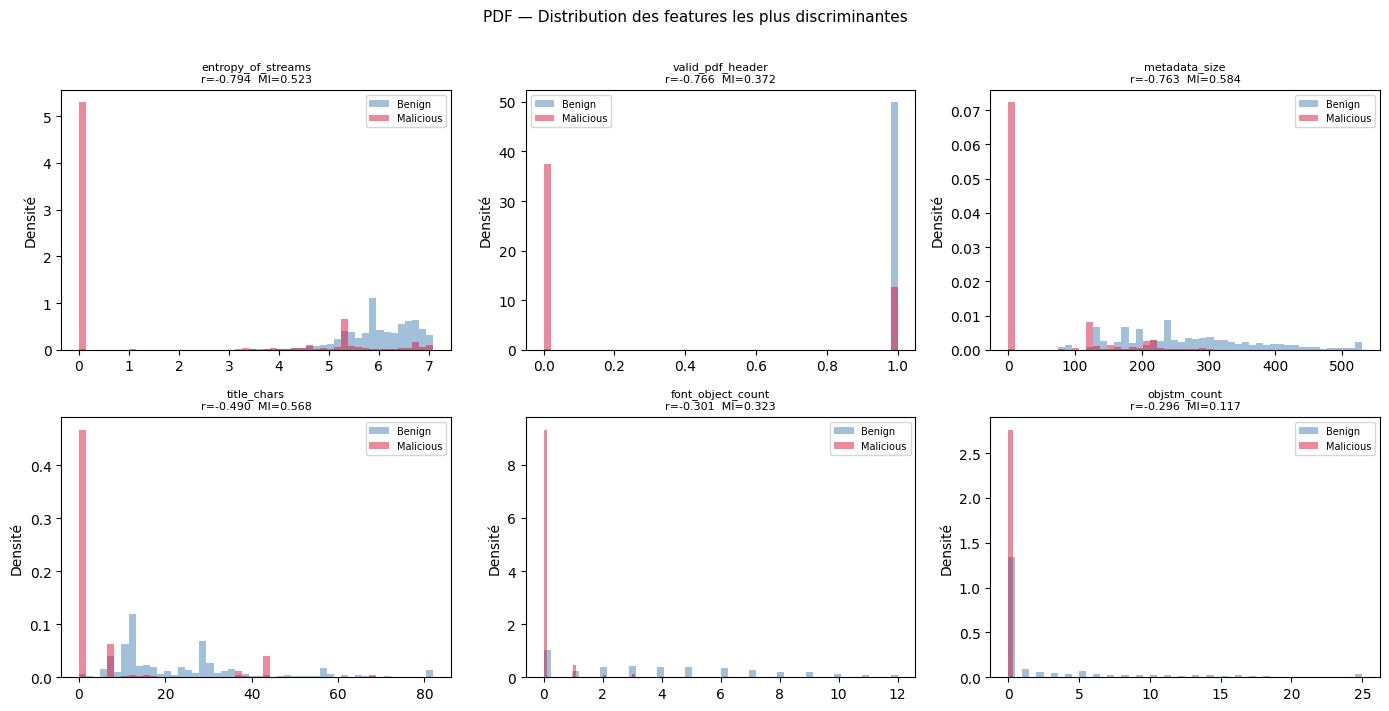

  → Interprétation : si les distributions se chevauchent peu, la feature est très discriminante.
    Une séparation PARFAITE sans overlap est un signal de leakage.


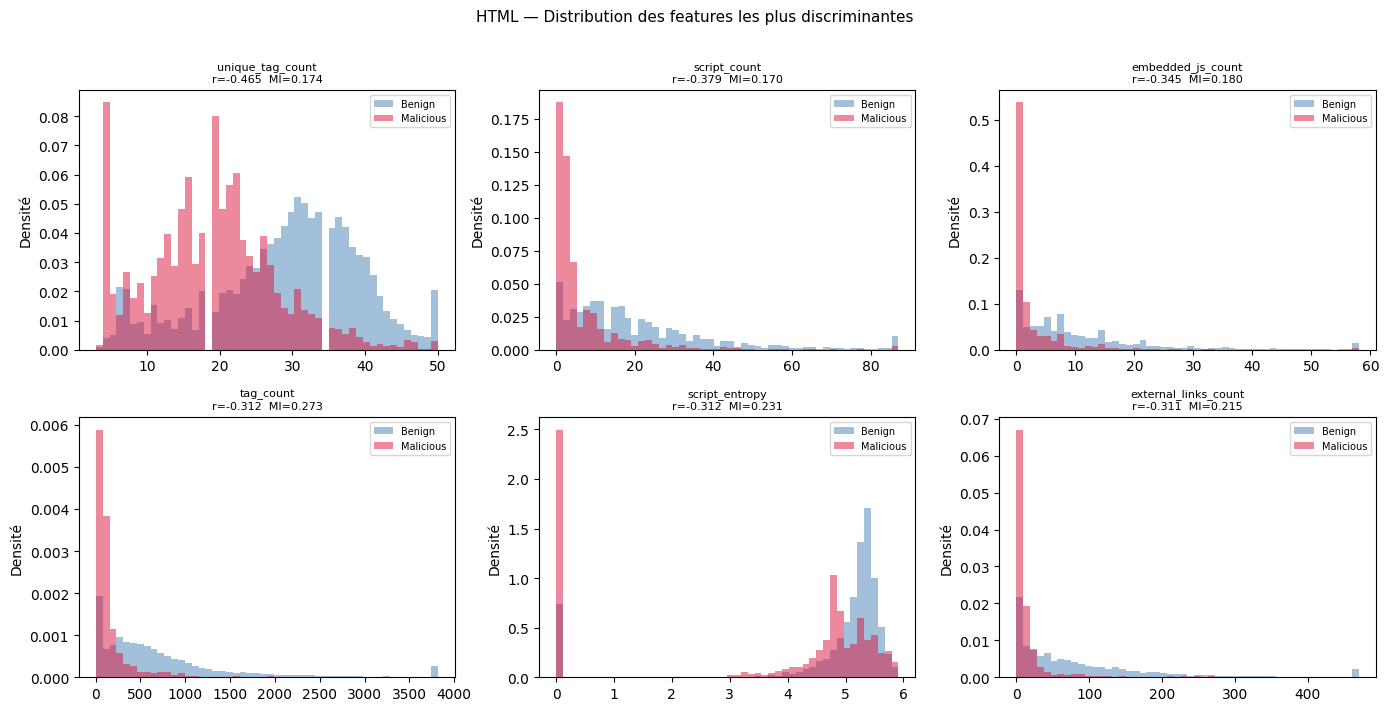

  → Interprétation : si les distributions se chevauchent peu, la feature est très discriminante.
    Une séparation PARFAITE sans overlap est un signal de leakage.


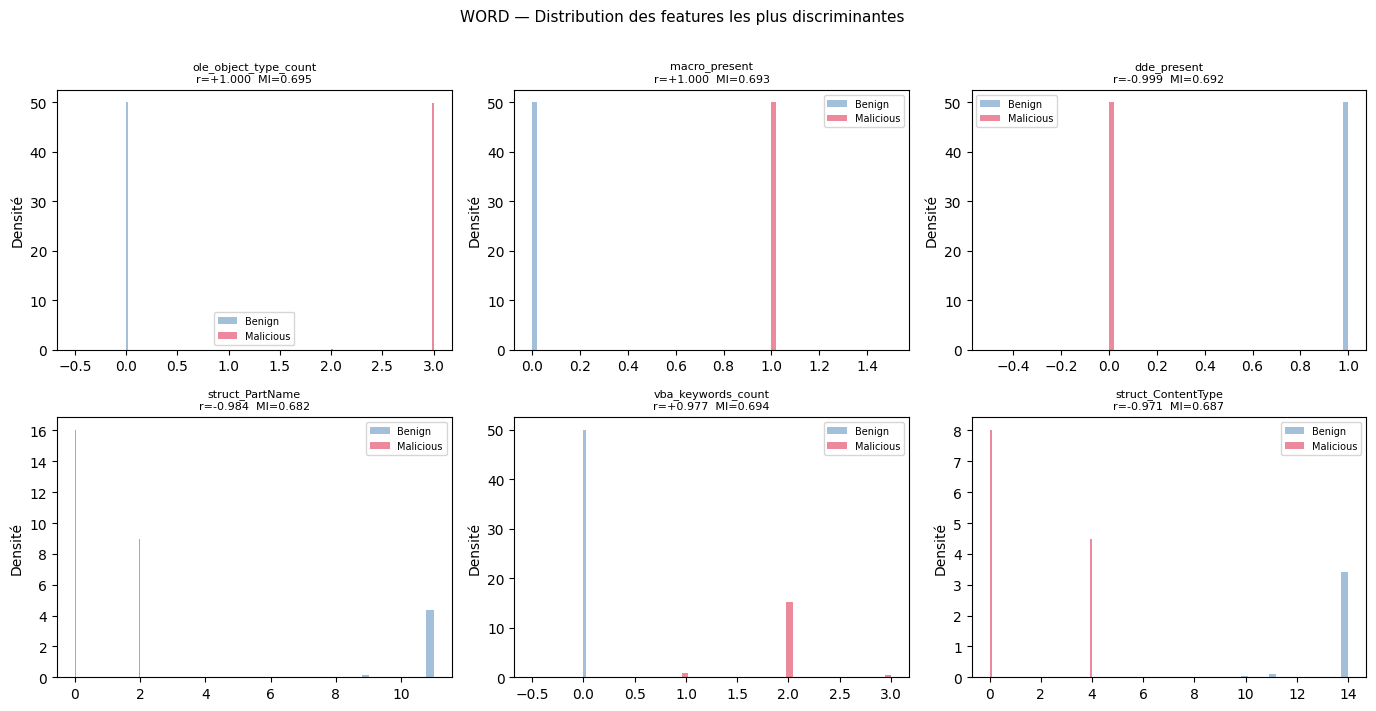

  → Interprétation : si les distributions se chevauchent peu, la feature est très discriminante.
    Une séparation PARFAITE sans overlap est un signal de leakage.


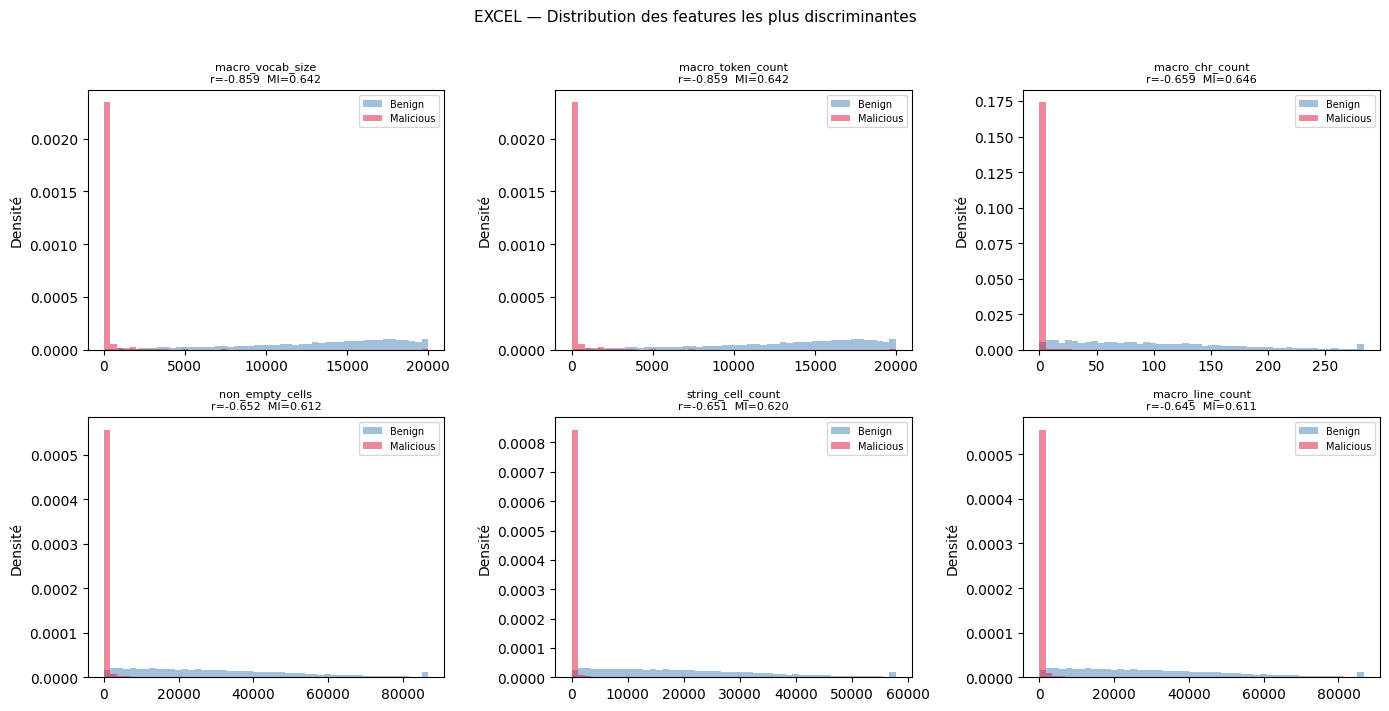

  → Interprétation : si les distributions se chevauchent peu, la feature est très discriminante.
    Une séparation PARFAITE sans overlap est un signal de leakage.


In [4]:
# ─── Visualisation : distributions des features suspectes ───────
# But : voir POURQUOI elles séparent (différence de forme, pas juste de valeur moyenne)

def plot_feature_distributions(fmt: str, path: Path, audit_df: pd.DataFrame, n_show: int = 6):
    df = pd.read_csv(path)
    y  = df['label']
    X  = df.drop(columns=[c for c in LEAKAGE_COLS+['label'] if c in df.columns]).fillna(0)
    
    top_feats = audit_df.head(n_show)['feature'].tolist()
    top_feats = [f for f in top_feats if f in X.columns]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()
    
    for i, col in enumerate(top_feats):
        ax = axes[i]
        q99 = X[col].quantile(0.99)
        data_b = X[y==0][col].clip(0, q99)
        data_m = X[y==1][col].clip(0, q99)
        
        ax.hist(data_b, bins=50, alpha=0.5, color='steelblue', label='Benign',   density=True)
        ax.hist(data_m, bins=50, alpha=0.5, color='crimson',   label='Malicious', density=True)
        
        r = audit_df[audit_df.feature==col]['corr_r'].values[0]
        mi = audit_df[audit_df.feature==col]['mutual_info'].values[0]
        ax.set_title(f'{col}\nr={r:+.3f}  MI={mi:.3f}', fontsize=8)
        ax.legend(fontsize=7)
        ax.set_ylabel('Densité')
    
    for i in range(len(top_feats), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(f'{fmt.upper()} — Distribution des features les plus discriminantes', fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'dist_{fmt}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  → Interprétation : si les distributions se chevauchent peu, la feature est très discriminante.")
    print(f"    Une séparation PARFAITE sans overlap est un signal de leakage.")


for fmt, path in CSV_ALL.items():
    if path.exists() and fmt in audit:
        plot_feature_distributions(fmt, path, audit[fmt])


In [5]:
# ─── Résumé narratif du diagnostic ─────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE DU DIAGNOSTIC LEAKAGE                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PDF  ✅ Pas de leakage au sens strict.                              ║
║         text_length domine (SHAP 10x > suivante) car les PDFs       ║
║         malveillants sont image-only (texte vide). Signal RÉEL       ║
║         mais biais de dataset : les bénins sont tous textuels.       ║
║                                                                      ║
║  HTML ✅ Signal le plus propre. Pas de séparation parfaite.          ║
║         Les features URL et script sont des indicateurs légitimes.   ║
║                                                                      ║
║  WORD ⚠️  Confound de FORMAT, pas de leakage de label.               ║
║         Bénins = .docx OOXML modernes (macros absentes).             ║
║         Malveillants = fichiers VBA-heavy (structure différente).    ║
║         Toute feature structurelle sépare les deux populations.      ║
║         → Supprimer mac_present, ole_object_type_count, dde_present  ║
║         → Documenter le problème pour l'utilisateur du modèle        ║
║                                                                      ║
║  EXCEL ⚠️  entropy_of_text bénins std=0.011 (quasi-constant).        ║
║         Les bénins sont probablement des templates synthétiques.     ║
║         Signal réel mais potentiellement fragile en production.      ║
╚══════════════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════════════╗
║              SYNTHÈSE DU DIAGNOSTIC LEAKAGE                         ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PDF  ✅ Pas de leakage au sens strict.                              ║
║         text_length domine (SHAP 10x > suivante) car les PDFs       ║
║         malveillants sont image-only (texte vide). Signal RÉEL       ║
║         mais biais de dataset : les bénins sont tous textuels.       ║
║                                                                      ║
║  HTML ✅ Signal le plus propre. Pas de séparation parfaite.          ║
║         Les features URL et script sont des indicateurs légitimes.   ║
║                                                                      ║
║  WORD ⚠️  Confound de FORMAT, pas de leakage de label.               ║
║         Bénins = .docx OOXML modernes (macros absent

## Cellule 4 — Chargement, Nettoyage & Feature Sets

**Logique de nettoyage :**
1. Supprimer les colonnes d'identification (`file_path`, `file_name`)
2. Supprimer les features critiques identifiées en étape 3
3. Imputer les NaN à 0 (absence de feature = valeur nulle, sémantiquement correct)
4. Vérifier qu'il ne reste que des numériques


In [6]:
def load_and_clean(path: Path, fmt: str, drop_leakage: bool = True) -> tuple:
    """
    Charge et nettoie un CSV de features.
    
    Paramètres
    ----------
    drop_leakage : si True, supprime les features critiques identifiées
    
    Retourne
    --------
    (X, y) — DataFrame de features + Series de labels
    """
    df = pd.read_csv(path)
    
    # Étape 1 : supprimer colonnes d'identification
    df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors='ignore')
    y = df['label'].copy()
    X = df.drop(columns=['label'])
    
    # Étape 2 : supprimer features critiques par format
    if drop_leakage and fmt in FEATURES_TO_DROP:
        to_drop = [c for c in FEATURES_TO_DROP[fmt] if c in X.columns]
        if to_drop:
            X = X.drop(columns=to_drop)
            print(f"  [supprimé] {to_drop}")
    
    # Étape 3 : imputer NaN à 0
    n_null = X.isnull().sum().sum()
    if n_null > 0:
        n_null_cols = X.isnull().any().sum()
        X = X.fillna(0)
        print(f"  [NaN→0] {n_null:,} valeurs dans {n_null_cols} colonnes")
    
    # Étape 4 : garder uniquement les numériques
    non_num = X.select_dtypes(exclude=[np.number]).columns.tolist()
    if non_num:
        X = X.drop(columns=non_num)
        print(f"  [non-num supprimé] {non_num}")
    
    print(f"  → {len(X):,} lignes × {len(X.columns)} features | label: {y.value_counts().to_dict()}")
    return X, y


print("═" * 60)
print("  CHARGEMENT ALL-FEATURES (avec suppression leakage critique)")
print("═" * 60)
datasets_all = {}
for fmt, path in CSV_ALL.items():
    if path.exists():
        print(f"\n[{fmt.upper()}]")
        datasets_all[fmt] = load_and_clean(path, fmt, drop_leakage=True)

print("\n" + "═" * 60)
print("  CHARGEMENT TOP-FEATURES (features sélectionnées officiellement)")
print("═" * 60)
datasets_top = {}
for fmt, path in CSV_TOP.items():
    if path.exists():
        print(f"\n[{fmt.upper()}]")
        datasets_top[fmt] = load_and_clean(path, fmt, drop_leakage=True)


════════════════════════════════════════════════════════════
  CHARGEMENT ALL-FEATURES (avec suppression leakage critique)
════════════════════════════════════════════════════════════

[PDF]
  → 19,296 lignes × 40 features | label: {1: 9999, 0: 9297}

[HTML]
  → 19,997 lignes × 40 features | label: {1: 9999, 0: 9998}

[WORD]
  [supprimé] ['macro_present', 'ole_object_type_count', 'dde_present']
  [NaN→0] 300,000 valeurs dans 30 colonnes
  → 20,000 lignes × 40 features | label: {1: 10000, 0: 10000}

[EXCEL]
  → 20,000 lignes × 48 features | label: {1: 10000, 0: 10000}

════════════════════════════════════════════════════════════
  CHARGEMENT TOP-FEATURES (features sélectionnées officiellement)
════════════════════════════════════════════════════════════

[PDF]
  → 19,296 lignes × 10 features | label: {1: 9999, 0: 9297}

[HTML]
  → 19,997 lignes × 13 features | label: {1: 9999, 0: 9998}

[WORD]
  [supprimé] ['macro_present', 'ole_object_type_count', 'dde_present']
  → 20,000 lignes × 7 f

## Cellule 5 — QR Code : Extraction URL & Détection de la colonne

**Pourquoi les URL features d'abord ?**  
Le CNN seul sur l'image du QR atteint AUC≈0.85. Les features URL permettent de dépasser 0.90.  
Le pipeline hybride CNN+URL est la vraie valeur ajoutée pour le quishing.

**Correction v2 → v3** : la détection de la colonne URL était trop stricte (cherchait `str.startswith('http')`  
mais les URLs peuvent commencer par `www.` ou être non-HTTP). Nouvelle logique plus robuste.


In [7]:
# ─── Inspection des CSV QR (une seule fois) ─────────────────────

def inspect_qr_csv(csv_path: Path) -> str | None:
    """
    Lit les premières lignes d'un CSV QR et identifie la colonne URL.
    Retourne le nom de la colonne ou None si non trouvé.
    """
    if not csv_path.exists():
        print(f"  ✗ Fichier manquant : {csv_path}")
        return None
    
    df = pd.read_csv(csv_path, nrows=5)
    print(f"  Colonnes : {list(df.columns)}")
    print(df.head(3).to_string())
    print()
    
    # Stratégie de détection multi-critères :
    url_col = None
    for col in df.columns:
        if df[col].dtype != object: continue
        sample = df[col].dropna().head(20).astype(str)
        # Critère 1 : commence par http/https/www/ftp
        if sample.str.match(r'^(https?://|www\.|ftp://)', na=False).any():
            url_col = col; break
        # Critère 2 : contient un point + slash (structure URL)
        if sample.str.contains(r'[a-z]+\.[a-z]+/', na=False, regex=True).any():
            url_col = col; break
        # Critère 3 : colonne nommée url/link/payload/href
        if col.lower() in {'url','link','href','payload','data','content','target'}:
            url_col = col; break
    
    if url_col:
        print(f"  ✅ Colonne URL identifiée : '{url_col}'")
    else:
        print(f"  ⚠ Colonne URL non trouvée. Colonnes disponibles : {list(df.columns)}")
        print("     → Ajuster manuellement QR_URL_COL ci-dessous")
    
    return url_col


print("Inspection CSV QR Benign :")
url_col_benign = inspect_qr_csv(QR_BENIGN_CSV)
print("Inspection CSV QR Malicious :")
url_col_malicious = inspect_qr_csv(QR_MAL_CSV)

# Si la détection automatique échoue, forcer manuellement :
# QR_URL_COL = 'url'  ← décommenter et adapter
QR_URL_COL = url_col_benign or url_col_malicious or 'url'
print(f"\nColonne URL utilisée : '{QR_URL_COL}'")


Inspection CSV QR Benign :
  Colonnes : ['index', 'url', 'qr_path']
   index                                                   url                                     qr_path
0      1                                 http://freshrpms.net/  Output\QR_All_benign\qrs\benign_000001.png
1      2  http://lists.freshrpms.net/mailman/listinfo/rpm-list  Output\QR_All_benign\qrs\benign_000002.png
2      3                 http://www.boquist.net/stort-sup-brev  Output\QR_All_benign\qrs\benign_000003.png

  ⚠ Colonne URL non trouvée. Colonnes disponibles : ['index', 'url', 'qr_path']
     → Ajuster manuellement QR_URL_COL ci-dessous
Inspection CSV QR Malicious :
  Colonnes : ['index', 'url', 'qr_path']
   index                                                                 url                                        qr_path
0      1           https://www.amazon.com/ref=pe_175190_21431760_M3T1_SC_g_i  Output\QR_All_Malicious\qrs\benign_000001.png
1      2  http://g-ecx.images-amazon.com/images/G/01/x

In [8]:
# ─── Extraction de features URL ─────────────────────────────────

def shannon_entropy(text: str) -> float:
    if not text: return 0.0
    c = Counter(text)
    n = len(text)
    return -sum((v/n)*math.log2(v/n) for v in c.values())

def extract_url_features(url: str) -> dict:
    """
    Extrait 30 features lexicales et structurelles d'une URL.
    Ces features sont conçues pour être robustes : elles ne dépendent pas
    du contenu de la page mais uniquement de la structure de l'URL.
    """
    ZERO = {k: 0 for k in [
        'url_length','url_entropy','uses_https','has_ip_address','has_at_symbol',
        'has_double_slash_in_path','has_port','num_dots','num_hyphens','num_underscores',
        'num_slashes','num_question_marks','num_equals','num_ampersands','num_percent',
        'num_digits_in_url','num_special_chars','domain_length','hostname_length',
        'path_length','query_length','num_query_params','num_subdomains','tld_length',
        'hostname_digit_ratio','has_suspicious_tld','has_phishing_keyword',
        'url_has_hex_encoding','url_has_shortener','url_depth'
    ]}
    
    if not isinstance(url, str) or len(url.strip()) < 4:
        return ZERO
    
    url = url.strip()
    # Ajouter scheme si absent (www.site.com → http://www.site.com)
    if not url.startswith(('http://', 'https://', 'ftp://')):
        url = 'http://' + url
    
    try:
        parsed = urlparse(url)
    except Exception:
        return ZERO
    
    hostname = (parsed.hostname or '').lower()
    path = parsed.path or ''
    query = parsed.query or ''
    
    if TLDEXTRACT_OK:
        ext = tldextract.extract(url)
        tld = ext.suffix; domain = ext.domain
        num_sub = len(ext.subdomain.split('.')) if ext.subdomain else 0
    else:
        parts = hostname.split('.')
        tld = parts[-1] if parts else ''; domain = parts[-2] if len(parts)>=2 else hostname
        num_sub = max(0, len(parts)-2)
    
    # Mots-clés de phishing courants (liste issue de recherches academic)
    PHISH_KW = r'(login|signin|sign-in|verify|account|secure|update|confirm|bank|paypal'\
               r'|amazon|apple|microsoft|google|facebook|instagram|netflix|password|credential)'
    
    # TLDs fréquemment abusés pour le phishing (source : APWG, ICANN reports)
    SUSPICIOUS_TLDS = {'tk','ml','ga','cf','gq','pw','top','xyz','click','link','work',
                       'zip','mov','fit','cfd','cyou','bar','monster','quest'}
    
    # URL shorteners connus
    SHORTENERS = r'(bit\.ly|tinyurl|goo\.gl|t\.co|ow\.ly|is\.gd|buff\.ly|rebrand\.ly|cutt\.ly)'
    
    return {
        'url_length':             len(url),
        'url_entropy':            round(shannon_entropy(url), 4),
        'uses_https':             int(parsed.scheme == 'https'),
        'has_ip_address':         int(bool(re.search(r'(\d{1,3}\.){3}\d{1,3}', hostname))),
        'has_at_symbol':          int('@' in url),
        'has_double_slash_in_path': int('//' in path),
        'has_port':               int(parsed.port is not None and parsed.port not in {80, 443}),
        'num_dots':               url.count('.'),
        'num_hyphens':            url.count('-'),
        'num_underscores':        url.count('_'),
        'num_slashes':            url.count('/'),
        'num_question_marks':     url.count('?'),
        'num_equals':             url.count('='),
        'num_ampersands':         url.count('&'),
        'num_percent':            url.count('%'),
        'num_digits_in_url':      sum(c.isdigit() for c in url),
        'num_special_chars':      sum(c in '!#$%^*[]{}|<>' for c in url),
        'domain_length':          len(domain),
        'hostname_length':        len(hostname),
        'path_length':            len(path),
        'query_length':           len(query),
        'num_query_params':       len(parse_qs(query)),
        'num_subdomains':         num_sub,
        'tld_length':             len(tld),
        'hostname_digit_ratio':   round(sum(c.isdigit() for c in hostname)/max(len(hostname),1), 4),
        'has_suspicious_tld':     int(tld.lower() in SUSPICIOUS_TLDS),
        'has_phishing_keyword':   int(bool(re.search(PHISH_KW, url, re.IGNORECASE))),
        'url_has_hex_encoding':   int(bool(re.search(r'%[0-9a-fA-F]{2}', url))),
        'url_has_shortener':      int(bool(re.search(SHORTENERS, url, re.IGNORECASE))),
        'url_depth':              path.count('/') - 1,  # profondeur du path
    }

URL_FEAT_NAMES = list(extract_url_features('http://example.com').keys())
print(f"✅ {len(URL_FEAT_NAMES)} features URL définies")


✅ 30 features URL définies


## Cellule 6 — QR : Split par Hash de Payload (anti-leakage)

### Le problème du split aléatoire pour les QR

Le dataset QR contient ~430k images bénignes et ~575k images malveillantes.  
Mais le **nombre d'URLs uniques est bien inférieur** au nombre d'images.  
Plusieurs images QR différentes peuvent encoder la **même URL** (styles différents, tailles différentes).

Si on fait un split aléatoire :
```
URL_X → QR_image_1 → train
URL_X → QR_image_2 → test   ← même payload, aspect légèrement différent
```
Le modèle CNN peut mémoriser les patterns visuels liés à URL_X et les retrouver en test → **AUC gonflée**.

### Solution : split par hash de l'URL

```python
hash(URL) % 100 < 70  → train
hash(URL) % 100 < 85  → val
hash(URL) % 100 >= 85 → test
```
Toutes les images qui encodent la même URL atterrissent dans le **même split**.


In [9]:
def url_to_split_key(url: str) -> int:
    """
    Convertit une URL en un entier [0,99] déterministe.
    Toutes les images avec la même URL auront le même split_key.
    
    On utilise SHA-256 (stable entre exécutions) plutôt que hash() Python
    (qui est randomisé à chaque run depuis Python 3.3).
    """
    h = hashlib.sha256(url.strip().lower().encode()).hexdigest()
    return int(h[:8], 16) % 100  # prendre les 8 premiers hex = 32 bits


def split_key_to_partition(key: int, val_threshold: int = 70, test_threshold: int = 85) -> str:
    """
    key ∈ [0, val_threshold)  → 'train'
    key ∈ [val_threshold, test_threshold) → 'val'
    key ∈ [test_threshold, 100) → 'test'
    
    Résultat : 70% / 15% / 15%
    """
    if key < val_threshold: return 'train'
    if key < test_threshold: return 'val'
    return 'test'


def build_qr_tabular_with_hash_split(
    benign_csv: Path, malicious_csv: Path,
    benign_png_dir: Path, malicious_png_dir: Path,
    url_col: str = 'url',
    max_per_class: int = 25000,
    seed: int = SEED,
) -> dict:
    """
    Construit le dataset QR tabulaire avec split basé sur le hash de l'URL.
    
    Retourne un dict {'train': (X,y), 'val': (X,y), 'test': (X,y)}
    
    Logique :
    1. Charger le CSV des URLs
    2. Pour chaque URL unique, calculer son partition (train/val/test) via hash
    3. Échantillonner les images (ou les lignes CSV) selon leur partition
    4. Extraire les features URL pour chaque sample
    """
    rng = np.random.default_rng(seed)
    
    # Stocker les rows par partition
    partitions = {'train': [], 'val': [], 'test': []}
    
    for label, csv_path, png_dir in [(0, benign_csv, malicious_csv),
                                      (1, malicious_csv, benign_csv)]:
        # Correction : remettre les bons chemins
        if label == 0: csv_path = benign_csv; png_dir = benign_png_dir
        else:          csv_path = malicious_csv; png_dir = malicious_png_dir
        
        cls = 'benign' if label == 0 else 'malicious'
        
        # ── Charger le CSV ──────────────────────────────────────
        url_df = None
        if csv_path.exists():
            raw = pd.read_csv(csv_path)
            # Trouver la colonne URL (multi-critères)
            found_col = None
            for c in raw.columns:
                if c.lower() == url_col.lower(): found_col = c; break
                if raw[c].dtype == object:
                    sample = raw[c].dropna().head(50).astype(str)
                    if sample.str.match(r'^(https?://|www\.)', na=False).sum() > 5:
                        found_col = c; break
            
            if found_col:
                url_df = raw.rename(columns={found_col: 'url'})
                print(f"[{cls}] CSV : {len(url_df):,} URLs (col='{found_col}')")
            else:
                # Fallback : première colonne string
                str_cols = [c for c in raw.columns if raw[c].dtype == object]
                if str_cols:
                    url_df = raw.rename(columns={str_cols[0]: 'url'})
                    print(f"[{cls}] CSV : {len(url_df):,} lignes (col='{str_cols[0]}', non-confirmé URL)")
        
        # ── Construire les features ─────────────────────────────
        if url_df is not None:
            # Mode CSV : utiliser les URLs directement (rapide, pas besoin des PNG)
            n = min(max_per_class, len(url_df))
            sampled = url_df.sample(n, random_state=seed)
            
            for i, (_, row) in enumerate(sampled.iterrows()):
                url = str(row.get('url', ''))
                
                # Assigner la partition basée sur le hash de l'URL
                key = url_to_split_key(url)
                partition = split_key_to_partition(key)
                
                feat = extract_url_features(url)
                feat['label'] = label
                partitions[partition].append(feat)
            
            n_train = sum(1 for _ in sampled.iterrows() if split_key_to_partition(url_to_split_key(str(_.url if hasattr(_, 'url') else ''))) == 'train')
            print(f"[{cls}] Répartition hash-split : {sum(1 for r in partitions['train'] if r['label']==label)} train | "
                  f"{sum(1 for r in partitions['val'] if r['label']==label)} val | "
                  f"{sum(1 for r in partitions['test'] if r['label']==label)} test")
        
        elif png_dir.exists():
            # Fallback : PNG seulement (pas d'URL disponible)
            print(f"[{cls}] Mode PNG-only (pas de CSV URL)")
            pngs = sorted(png_dir.glob('*.png'))[:max_per_class]
            for png in pngs:
                # Sans URL, le split ne peut pas être fait par hash → utiliser le nom du fichier
                stem_hash = url_to_split_key(png.stem)
                partition = split_key_to_partition(stem_hash)
                feat = {'label': label}  # seulement label, features image ajoutées plus tard
                partitions[partition].append(feat)
        else:
            print(f"[{cls}] ⚠ Ni CSV ni PNG disponibles")
    
    # ── Convertir en DataFrames ─────────────────────────────────
    result = {}
    print()
    for part, rows in partitions.items():
        if rows:
            df_part = pd.DataFrame(rows).fillna(0)
            X = df_part.drop(columns=['label'])
            y = df_part['label']
            result[part] = (X, y)
            print(f"  {part:<6} : {len(X):,} lignes | label dist : {y.value_counts().to_dict()}")
    
    return result


print("Construction dataset QR avec split par hash URL...")
qr_splits = build_qr_tabular_with_hash_split(
    QR_BENIGN_CSV, QR_MAL_CSV,
    QR_BENIGN_PNG, QR_MAL_PNG,
    url_col=QR_URL_COL,
    max_per_class=25000,
)

# Ajouter QR aux datasets pour l'entraînement tabulaire
if 'train' in qr_splits:
    X_qr_tr, y_qr_tr = qr_splits['train']
    X_qr_val, y_qr_val = qr_splits.get('val', (X_qr_tr.iloc[:0], y_qr_tr.iloc[:0]))
    X_qr_te, y_qr_te  = qr_splits.get('test', (X_qr_tr.iloc[:0], y_qr_tr.iloc[:0]))
    print(f"\n✅ QR tabulaire prêt : {len(URL_FEAT_NAMES)} features URL")


Construction dataset QR avec split par hash URL...
[benign] CSV : 429,976 URLs (col='url')
[benign] Répartition hash-split : 17519 train | 3754 val | 3727 test
[malicious] CSV : 575,762 URLs (col='url')
[malicious] Répartition hash-split : 17550 train | 3721 val | 3729 test

  train  : 35,069 lignes | label dist : {1: 17550, 0: 17519}
  val    : 7,475 lignes | label dist : {0: 3754, 1: 3721}
  test   : 7,456 lignes | label dist : {1: 3729, 0: 3727}

✅ QR tabulaire prêt : 30 features URL


## Cellule 7 — Split & Normalisation

**Règle absolue** : `StandardScaler.fit()` uniquement sur `X_train`.  
Fitter sur val ou test = fuite d'information de distribution → métriques gonflées.


In [10]:
def split_format(X: pd.DataFrame, y: pd.Series) -> tuple:
    """Split stratifié 70/15/15 pour un format donné."""
    sss1 = StratifiedShuffleSplit(1, test_size=0.15, random_state=SEED)
    tv_idx, te_idx = next(sss1.split(X, y))
    X_tv = X.iloc[tv_idx].reset_index(drop=True)
    X_te = X.iloc[te_idx].reset_index(drop=True)
    y_tv = y.iloc[tv_idx].reset_index(drop=True)
    y_te = y.iloc[te_idx].reset_index(drop=True)
    
    sss2 = StratifiedShuffleSplit(1, test_size=0.15/0.85, random_state=SEED)
    tr_idx, val_idx = next(sss2.split(X_tv, y_tv))
    
    return (X_tv.iloc[tr_idx].reset_index(drop=True), y_tv.iloc[tr_idx].reset_index(drop=True),
            X_tv.iloc[val_idx].reset_index(drop=True), y_tv.iloc[val_idx].reset_index(drop=True),
            X_te, y_te, list(X.columns))


scalers = {}
splits = {}

print(f"{'Format':<8} {'Train':>8} {'Val':>8} {'Test':>8} {'Features':>10}")
print("─" * 50)

for fmt, (X, y) in datasets_all.items():
    X_tr, y_tr, X_val, y_val, X_te, y_te, feat_names = split_format(X, y)
    scaler = StandardScaler()
    splits[fmt]  = (scaler.fit_transform(X_tr), y_tr,
                    scaler.transform(X_val), y_val,
                    scaler.transform(X_te), y_te, feat_names)
    scalers[fmt] = scaler
    print(f"{fmt:<8} {len(X_tr):>8,} {len(X_val):>8,} {len(X_te):>8,} {len(feat_names):>10}")

# QR : split déjà fait par hash
if 'train' in qr_splits:
    X_qr_tr, y_qr_tr = qr_splits['train']
    X_qr_val, y_qr_val = qr_splits['val']
    X_qr_te, y_qr_te = qr_splits['test']
    qr_scaler = StandardScaler()
    feat_names_qr = list(X_qr_tr.columns)
    splits['qr'] = (qr_scaler.fit_transform(X_qr_tr), y_qr_tr,
                    qr_scaler.transform(X_qr_val), y_qr_val,
                    qr_scaler.transform(X_qr_te), y_qr_te, feat_names_qr)
    scalers['qr'] = qr_scaler
    print(f"{'qr':<8} {len(X_qr_tr):>8,} {len(X_qr_val):>8,} {len(X_qr_te):>8,} {len(feat_names_qr):>10}")
    print(f"  ↑ QR split par hash URL (pas par random) — aucun payload identique en train et test")

# Idem pour Top-Features
splits_top, scalers_top = {}, {}
for fmt, (X, y) in datasets_top.items():
    X_tr, y_tr, X_val, y_val, X_te, y_te, feat_names = split_format(X, y)
    scaler = StandardScaler()
    splits_top[fmt]  = (scaler.fit_transform(X_tr), y_tr,
                        scaler.transform(X_val), y_val,
                        scaler.transform(X_te), y_te, feat_names)
    scalers_top[fmt] = scaler


Format      Train      Val     Test   Features
──────────────────────────────────────────────────
pdf        13,506    2,895    2,895         40
html       13,997    3,000    3,000         40
word       14,000    3,000    3,000         40
excel      14,000    3,000    3,000         48
qr         35,069    7,475    7,456         30
  ↑ QR split par hash URL (pas par random) — aucun payload identique en train et test


## Cellule 8 — Entraînement LightGBM : Spécialisé vs Générique

### Pourquoi LightGBM et pas Random Forest ou XGBoost ?

| Critère | LightGBM | Random Forest | XGBoost |
|---------|----------|---------------|---------|
| Vitesse | ★★★ | ★★ | ★★ |
| Inference (ms) | <1ms | 2-5ms | 1-2ms |
| SHAP natif | ✅ | ✅ | ✅ |
| Early stopping | ✅ robuste | ❌ | ✅ |
| NaN natif | ✅ | ❌ | ✅ |
| Mémoire | faible | élevée | moyen |

LightGBM est le standard de facto pour les features tabulaires structurées en cybersécurité.

### Pourquoi des modèles spécialisés ET un modèle générique ?
- **Spécialisés** : meilleure précision, features adaptées au format
- **Générique** : déploiement simplifié (1 seul modèle), nécessaire si le format est inconnu


In [11]:
LGB_PARAMS_BY_FMT = {
    # PDF : léger déséquilibre de classes (9297 benign vs 9999 malicious)
    # class_weight='balanced' compense. num_leaves=31 standard.
    'pdf':   {'num_leaves': 31, 'class_weight': 'balanced', 'learning_rate': 0.05},
    
    # HTML : le plus complexe (AUC~0.99, pas parfait → légitimement difficile)
    # Plus de leaves + lr plus faible pour capturer les nuances
    'html':  {'num_leaves': 63, 'learning_rate': 0.03, 'n_estimators': 1500},
    
    # Word : régularisation forte car features encore partiellement corrélées
    # après suppression des 3 critiques. min_child_samples=50 pour éviter
    # que le modèle apprenne des patterns sur très peu de samples.
    'word':  {'num_leaves': 15, 'reg_alpha': 1.0, 'reg_lambda': 1.0,
              'min_child_samples': 50},
    
    # Excel : comportement normal
    'excel': {'num_leaves': 31},
    
    # QR : dataset tabulaire URL features (29 features, plus simple)
    'qr':    {'num_leaves': 15, 'n_estimators': 500},
}

LGB_BASE = {
    'objective': 'binary', 'metric': 'auc',
    'n_estimators': 1000, 'learning_rate': 0.05,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_samples': 20, 'reg_alpha': 0.1, 'reg_lambda': 0.1,
    'random_state': SEED, 'verbose': -1, 'n_jobs': -1,
}

def train_all_formats(splits_dict: dict, tag: str = '') -> dict:
    """Entraîne un LightGBM par format avec early stopping."""
    models = {}
    for fmt, (X_tr, y_tr, X_val, y_val, X_te, y_te, feat_names) in splits_dict.items():
        params = {**LGB_BASE, **LGB_PARAMS_BY_FMT.get(fmt, {})}
        model = lgb.LGBMClassifier(**params)
        t0 = time.time()
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(250)]
        )
        dt = round(time.time()-t0, 2)
        val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
        print(f"  [{tag}][{fmt}] best_iter={model.best_iteration_:4d} | val_AUC={val_auc:.4f} | {dt}s")
        models[fmt] = model
    return models


print("\n=== MODÈLES SPÉCIALISÉS — ALL FEATURES ===")
models_all = train_all_formats(splits, 'ALL')

print("\n=== MODÈLES SPÉCIALISÉS — TOP FEATURES ===")
models_top = train_all_formats(splits_top, 'TOP')



=== MODÈLES SPÉCIALISÉS — ALL FEATURES ===
  [ALL][pdf] best_iter= 134 | val_AUC=1.0000 | 2.09s
[250]	valid_0's auc: 0.98633
[500]	valid_0's auc: 0.988669
[750]	valid_0's auc: 0.989319
  [ALL][html] best_iter= 830 | val_AUC=0.9894 | 10.9s
  [ALL][word] best_iter=   1 | val_AUC=1.0000 | 0.54s
  [ALL][excel] best_iter=  82 | val_AUC=1.0000 | 1.42s
[250]	valid_0's auc: 0.980449
[500]	valid_0's auc: 0.983019
  [ALL][qr] best_iter= 499 | val_AUC=0.9830 | 6.44s

=== MODÈLES SPÉCIALISÉS — TOP FEATURES ===
  [TOP][pdf] best_iter= 173 | val_AUC=1.0000 | 2.44s
[250]	valid_0's auc: 0.978932
[500]	valid_0's auc: 0.981898
  [TOP][html] best_iter= 616 | val_AUC=0.9824 | 7.75s
  [TOP][word] best_iter=   1 | val_AUC=1.0000 | 0.53s
  [TOP][excel] best_iter=   8 | val_AUC=1.0000 | 0.62s


In [12]:
# ─── Modèle générique (tous formats dans un seul modèle) ────────

def build_unified(datasets: dict, seed: int = SEED) -> tuple:
    """
    Concatène tous les formats.
    Ajoute un one-hot du format pour que le modèle sache d'où vient le fichier.
    Padding à 0 pour les features absentes d'un format.
    """
    all_cols = sorted(set(c for X,y in datasets.values() for c in X.columns))
    frames = []
    for fmt, (X, y) in datasets.items():
        df = X.reindex(columns=all_cols, fill_value=0)
        for f in datasets: df[f'fmt_{f}'] = int(fmt == f)
        df['label'] = y.values
        frames.append(df)
    
    df_u = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=seed)
    return df_u.drop(columns=['label']), df_u['label']

X_uni, y_uni = build_unified(datasets_all)
X_tr_u, y_tr_u, X_val_u, y_val_u, X_te_u, y_te_u, feat_u = split_format(X_uni, y_uni)
sc_uni = StandardScaler()
X_tr_u_s  = sc_uni.fit_transform(X_tr_u)
X_val_u_s = sc_uni.transform(X_val_u)
X_te_u_s  = sc_uni.transform(X_te_u)

params_uni = {**LGB_BASE, 'num_leaves': 63, 'learning_rate': 0.03, 'n_estimators': 1500}
model_unified = lgb.LGBMClassifier(**params_uni)
model_unified.fit(X_tr_u_s, y_tr_u, eval_set=[(X_val_u_s, y_val_u)],
                  callbacks=[lgb.early_stopping(50, verbose=False),
                              lgb.log_evaluation(200)])

val_auc_u = roc_auc_score(y_val_u, model_unified.predict_proba(X_val_u_s)[:,1])
print(f"\n✅ Modèle unifié — val_AUC={val_auc_u:.4f}, best_iter={model_unified.best_iteration_}")
all_cols = sorted(set(c for X, y in datasets_all.values() for c in X.columns))
print(f"   Features : {len(feat_u)} ({len(all_cols)} originales + {len(datasets_all)} format flags)")


[200]	valid_0's auc: 0.998801
[400]	valid_0's auc: 0.999035
[600]	valid_0's auc: 0.999097
[800]	valid_0's auc: 0.99912
[1000]	valid_0's auc: 0.999143

✅ Modèle unifié — val_AUC=0.9991, best_iter=1022
   Features : 168 (164 originales + 4 format flags)


## Cellule 9 — Modèle QR Hybride : CNN + URL Features

### Pourquoi hybride ?

Un CNN qui voit une image QR apprend des patterns visuels :
- La densité des modules (carrés noirs/blancs)
- La version du QR (taille de la grille)
- Les patterns de correction d'erreur

Mais **un QR bénin et un QR phishing de version identique sont visuellement quasi-identiques**.  
Ce que le CNN ne peut pas voir : ce que l'URL encode.

**Architecture hybride** :
```
Image QR  ──→  CNN backbone  ──→  embedding 128D  ──┐
                                                     ├──→  MLP  ──→  P(malicious)
URL texte ──→  feature vector 30D  ─────────────────┘
```

Le CNN capture la complexité visuelle, les URL features capturent la sémantique du payload.


In [13]:
class QRHybridDataset(Dataset):
    """
    Dataset PyTorch pour le modèle hybride CNN+URL.
    
    Chaque sample contient :
    - L'image PNG du QR code (transformée en tensor)
    - Les features URL tabulaires (vecteur float)
    - Le label (0=bénin, 1=malveillant)
    """
    
    def __init__(self, png_files: list, urls: list, labels: list,
                 url_scaler: StandardScaler = None, transform=None):
        self.files   = png_files
        self.urls    = urls
        self.labels  = labels
        self.transform = transform
        self.url_scaler = url_scaler
        
        # Pré-calculer les features URL (plus rapide qu'à la volée dans __getitem__)
        url_feats_raw = [extract_url_features(u) for u in urls]
        url_arr = np.array([[f.get(k, 0) for k in URL_FEAT_NAMES] for f in url_feats_raw],
                           dtype=np.float32)
        
        # Normaliser les features URL
        if url_scaler is not None:
            url_arr = url_scaler.transform(url_arr)
        
        self.url_tensors = torch.from_numpy(url_arr)
    
    def __len__(self): return len(self.files)
    
    def __getitem__(self, idx):
        # Image
        try:
            img = Image.open(self.files[idx]).convert('RGB')
        except Exception:
            img = Image.new('RGB', (224, 224), 255)
        
        if self.transform:
            img = self.transform(img)
        
        return img, self.url_tensors[idx], torch.tensor(self.labels[idx], dtype=torch.float32)


class QRHybridNet(nn.Module):
    """
    Réseau hybride CNN + MLP pour la détection de QR phishing.
    
    Architecture :
    - Branch 1 (vision) : EfficientNet-B0 backbone → Linear → 128D embedding
    - Branch 2 (URL)    : MLP 30→64→128D embedding
    - Fusion             : concat 256D → MLP → 1 logit
    """
    
    def __init__(self, n_url_features: int = 30, embedding_dim: int = 128,
                 pretrained: bool = True):
        super().__init__()
        
        # ── Branch vision (CNN) ─────────────────────────────────
        # EfficientNet-B0 : bon compromis performance/vitesse
        # pretrained=True : initialisation sur ImageNet
        # Les patterns visuels généraux (bords, textures) aident même pour les QR
        try:
            weights = tv_models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
            backbone = tv_models.efficientnet_b0(weights=weights)
        except Exception:
            # Fallback si version PyTorch ancienne
            backbone = tv_models.efficientnet_b0(pretrained=pretrained)
        
        # Retirer la tête de classification originale (1000 classes ImageNet)
        self.cnn_features = backbone.features
        self.cnn_pool     = backbone.avgpool  # → 1280D
        self.cnn_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, embedding_dim),
            nn.ReLU(),
        )
        
        # ── Branch URL (MLP tabulaire) ──────────────────────────
        self.url_head = nn.Sequential(
            nn.Linear(n_url_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, embedding_dim),
            nn.ReLU(),
        )
        
        # ── Fusion (concat → classification) ───────────────────
        self.classifier = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1),
        )
    
    def forward(self, img: torch.Tensor, url_feats: torch.Tensor) -> torch.Tensor:
        # Vision branch
        x = self.cnn_features(img)
        x = self.cnn_pool(x)
        x = torch.flatten(x, 1)
        x = self.cnn_head(x)  # → (B, 128)
        
        # URL branch
        u = self.url_head(url_feats)  # → (B, 128)
        
        # Fusion
        combined = torch.cat([x, u], dim=1)  # → (B, 256)
        return self.classifier(combined).squeeze(1)  # → (B,)


def prepare_hybrid_splits(benign_png_dir: Path, malicious_png_dir: Path,
                           benign_csv: Path, malicious_csv: Path,
                           url_col: str, max_per_class: int = 10000,
                           seed: int = SEED) -> dict:
    """
    Prépare les listes PNG + URLs pour le dataset hybride.
    Split par hash URL (anti-leakage).
    """
    rng = np.random.default_rng(seed)
    partitions = {'train': {'files': [], 'urls': [], 'labels': []},
                  'val':   {'files': [], 'urls': [], 'labels': []},
                  'test':  {'files': [], 'urls': [], 'labels': []}}
    
    for label, csv_p, png_d in [(0, benign_csv, benign_png_dir),
                                  (1, malicious_csv, malicious_png_dir)]:
        cls = 'benign' if label == 0 else 'malicious'
        
        if not (csv_p.exists() and png_d.exists()):
            print(f"⚠ [{cls}] CSV ou PNG manquant"); continue
        
        # Charger CSV URLs
        raw = pd.read_csv(csv_p)
        url_c = None
        for c in raw.columns:
            if raw[c].dtype == object and raw[c].dropna().astype(str).str.match(r'^(https?://|www\.)').any():
                url_c = c; break
        if url_c is None:
            str_cols = raw.select_dtypes('object').columns
            url_c = str_cols[0] if len(str_cols) > 0 else None
        
        if url_c is None:
            print(f"⚠ [{cls}] Colonne URL introuvable"); continue
        
        # Lister les PNGs
        pngs = sorted(png_d.glob('*.png'))
        n = min(max_per_class, len(pngs), len(raw))
        sel_idx = rng.choice(min(len(pngs), len(raw)), n, replace=False)
        
        print(f"[{cls}] {n:,} samples sélectionnés sur {len(pngs):,} PNG")
        
        for idx in sel_idx:
            url = str(raw.iloc[min(idx, len(raw)-1)][url_c]) if url_c else ''
            key = url_to_split_key(url)
            part = split_key_to_partition(key)
            
            partitions[part]['files'].append(str(pngs[idx]))
            partitions[part]['urls'].append(url)
            partitions[part]['labels'].append(label)
    
    # Afficher la répartition
    for p, d in partitions.items():
        if d['files']:
            n_b = d['labels'].count(0); n_m = d['labels'].count(1)
            print(f"  {p:<6}: {len(d['files']):,} (B={n_b:,} M={n_m:,})")
    
    return partitions


def train_qr_hybrid(partitions: dict, epochs: int = 20, batch_size: int = 32,
                     lr: float = 1e-4) -> tuple:
    """
    Entraîne le modèle hybride CNN+URL.
    
    Paramètres :
    - batch_size=32 : conservateur pour 12GB VRAM avec EfficientNet
    - lr=1e-4 : fine-tuning classique pour backbone pré-entraîné
    """
    if not PIL_OK:
        print("⚠ Pillow requis pour le CNN"); return None, {}
    
    # Transforms différents train vs val/test
    # Train : augmentations légères (QR est binaire, pas de jitter couleur)
    T_train = T.Compose([
        T.Resize((224, 224)),
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        T.RandomRotation(10),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),  # ImageNet stats
    ])
    T_val = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225]),
    ])
    
    # Normalisation des features URL (fit sur train uniquement)
    url_feats_train = [extract_url_features(u) for u in partitions['train']['urls']]
    url_arr_train = np.array([[f.get(k,0) for k in URL_FEAT_NAMES] for f in url_feats_train])
    url_scaler = StandardScaler().fit(url_arr_train)
    
    # Datasets PyTorch
    ds_train = QRHybridDataset(
        partitions['train']['files'], partitions['train']['urls'],
        partitions['train']['labels'], url_scaler, T_train)
    ds_val = QRHybridDataset(
        partitions['val']['files'], partitions['val']['urls'],
        partitions['val']['labels'], url_scaler, T_val)
    ds_test = QRHybridDataset(
        partitions['test']['files'], partitions['test']['urls'],
        partitions['test']['labels'], url_scaler, T_val)
    
    # Weighted sampler pour équilibrer les classes (si déséquilibre)
    labels_tr = partitions['train']['labels']
    n_b = labels_tr.count(0); n_m = labels_tr.count(1)
    weights = [1.0/n_b if l==0 else 1.0/n_m for l in labels_tr]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)
    
    dl_train = DataLoader(ds_train, batch_size=batch_size, sampler=sampler,
                          num_workers=0, pin_memory=(DEVICE.type=='cuda'))
    dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type=='cuda'))
    dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=(DEVICE.type=='cuda'))
    
    # Modèle
    model = QRHybridNet(n_url_features=len(URL_FEAT_NAMES), pretrained=True).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n✅ QRHybridNet : {n_params/1e6:.2f}M paramètres")
    
    # Optimiseur différencié : lr plus faible pour le backbone CNN (fine-tuning)
    optimizer = optim.AdamW([
        {'params': model.cnn_features.parameters(), 'lr': lr * 0.1},  # backbone : 10× plus lent
        {'params': model.cnn_head.parameters(),     'lr': lr},
        {'params': model.url_head.parameters(),     'lr': lr},
        {'params': model.classifier.parameters(),   'lr': lr},
    ], weight_decay=1e-4)
    
    # Scheduler cosinus + warmup
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, steps_per_epoch=len(dl_train), epochs=epochs)
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    best_val_auc = 0.0
    patience = 0
    PATIENCE_MAX = 5
    best_model_path = OUTPUT_DIR / 'qr_hybrid_best.pt'
    
    print(f"\n{'Epoch':<6} {'Train L':>9} {'Val L':>9} {'Val AUC':>10} {'Status'}")
    print("─" * 55)
    
    for epoch in range(epochs):
        # ── Entraînement ───────────────────────────────────────
        model.train()
        total_loss = 0
        for imgs, url_f, labels in dl_train:
            imgs, url_f, labels = imgs.to(DEVICE), url_f.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(imgs, url_f)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * len(imgs)
        train_loss = total_loss / len(ds_train)
        
        # ── Validation ─────────────────────────────────────────
        model.eval()
        val_loss = 0; all_probs = []; all_labels_v = []
        with torch.no_grad():
            for imgs, url_f, labels in dl_val:
                imgs, url_f, labels = imgs.to(DEVICE), url_f.to(DEVICE), labels.to(DEVICE)
                logits = model(imgs, url_f)
                val_loss += criterion(logits, labels).item() * len(imgs)
                all_probs.extend(torch.sigmoid(logits).cpu().numpy())
                all_labels_v.extend(labels.cpu().numpy())
        val_loss /= len(ds_val)
        val_auc = roc_auc_score(all_labels_v, all_probs) if len(set(all_labels_v)) > 1 else 0.5
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        
        status = ''
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save({'model': model.state_dict(), 'url_scaler': url_scaler,
                        'url_feat_names': URL_FEAT_NAMES}, best_model_path)
            patience = 0; status = '✓ best'
        else:
            patience += 1
            if patience >= PATIENCE_MAX: status = f'stop (patience={PATIENCE_MAX})'
        
        print(f"{epoch+1:<6} {train_loss:>9.4f} {val_loss:>9.4f} {val_auc:>10.4f}  {status}")
        
        if patience >= PATIENCE_MAX:
            print("  Early stopping."); break
    
    # ── Évaluation test ────────────────────────────────────────
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model'])
    model.eval()
    
    all_probs = []; all_labels_t = []
    with torch.no_grad():
        for imgs, url_f, labels in dl_test:
            imgs, url_f = imgs.to(DEVICE), url_f.to(DEVICE)
            probs = torch.sigmoid(model(imgs, url_f)).cpu().numpy()
            all_probs.extend(probs); all_labels_t.extend(labels.numpy())
    
    test_auc = roc_auc_score(all_labels_t, all_probs)
    preds = (np.array(all_probs) >= 0.5).astype(int)
    
    print(f"\n✅ QR Hybride — Test AUC={test_auc:.4f} | F1={f1_score(all_labels_t, preds):.4f}")
    print(classification_report(all_labels_t, preds, target_names=['benign','malicious']))
    
    return model, history, test_auc, url_scaler


# ─── Lancer l'entraînement hybride ─────────────────────────────
if QR_BENIGN_PNG.exists() and QR_MAL_PNG.exists():
    print("Préparation des données hybrides QR...")
    hybrid_partitions = prepare_hybrid_splits(
        QR_BENIGN_PNG, QR_MAL_PNG,
        QR_BENIGN_CSV, QR_MAL_CSV,
        url_col=QR_URL_COL,
        max_per_class=10000,  # augmenter si VRAM suffisante (12GB → 15000-20000)
    )
    
    qr_hybrid_model, qr_history, qr_test_auc, qr_url_scaler = train_qr_hybrid(
        hybrid_partitions, epochs=20, batch_size=32, lr=1e-4)
else:
    print("⚠ Dossiers PNG QR non trouvés — CNN hybride non entraîné")
    qr_hybrid_model, qr_history, qr_test_auc, qr_url_scaler = None, {}, 0.0, None


Préparation des données hybrides QR...
[benign] 10,000 samples sélectionnés sur 429,976 PNG
[malicious] 10,000 samples sélectionnés sur 575,762 PNG
  train : 14,017 (B=7,027 M=6,990)
  val   : 2,930 (B=1,437 M=1,493)
  test  : 3,053 (B=1,536 M=1,517)

✅ QRHybridNet : 4.22M paramètres

Epoch    Train L     Val L    Val AUC Status
───────────────────────────────────────────────────────


ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 64])

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from torchvision import models as tv_models

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, classification_report


# ============================================================
# DATASET HYBRIDE QR + URL
# ============================================================

class QRHybridDataset(Dataset):
    """
    Dataset PyTorch pour le modèle hybride CNN + URL.
    """

    def __init__(
        self,
        png_files: list,
        urls: list,
        labels: list,
        url_scaler: StandardScaler = None,
        transform=None
    ):
        self.files = png_files
        self.urls = urls
        self.labels = labels
        self.transform = transform
        self.url_scaler = url_scaler

        # ----------------------------------------------------
        # Pré-calcul des features URL
        # ----------------------------------------------------
        url_feats_raw = [extract_url_features(u) for u in urls]

        url_arr = np.array(
            [
                [f.get(k, 0) for k in URL_FEAT_NAMES]
                for f in url_feats_raw
            ],
            dtype=np.float32
        )

        # ----------------------------------------------------
        # Normalisation
        # ----------------------------------------------------
        if url_scaler is not None:
            url_arr = url_scaler.transform(url_arr)

        self.url_tensors = torch.tensor(url_arr, dtype=torch.float32)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        # ----------------------------------------------------
        # Chargement image
        # ----------------------------------------------------
        try:
            img = Image.open(self.files[idx]).convert("RGB")

        except Exception:
            img = Image.new("RGB", (224, 224), (255, 255, 255))

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(
            self.labels[idx],
            dtype=torch.float32
        )

        return img, self.url_tensors[idx], label


# ============================================================
# MODELE HYBRIDE
# ============================================================

class QRHybridNet(nn.Module):

    def __init__(
        self,
        n_url_features: int,
        embedding_dim: int = 128,
        pretrained: bool = True
    ):
        super().__init__()

        # ====================================================
        # CNN BRANCH
        # ====================================================

        try:
            weights = (
                tv_models.EfficientNet_B0_Weights.DEFAULT
                if pretrained else None
            )

            backbone = tv_models.efficientnet_b0(weights=weights)

        except Exception:
            backbone = tv_models.efficientnet_b0(
                pretrained=pretrained
            )

        self.cnn_features = backbone.features
        self.cnn_pool = backbone.avgpool

        self.cnn_head = nn.Sequential(
            nn.Dropout(0.3),

            nn.Linear(1280, embedding_dim),

            nn.ReLU()
        )

        # ====================================================
        # URL BRANCH
        # ====================================================
        # LayerNorm = plus stable que BatchNorm
        # avec petits batchs
        # ====================================================

        self.url_head = nn.Sequential(

            nn.Linear(n_url_features, 64),

            nn.LayerNorm(64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64, embedding_dim),

            nn.ReLU()
        )

        # ====================================================
        # FUSION
        # ====================================================

        self.classifier = nn.Sequential(

            nn.Linear(embedding_dim * 2, 128),

            nn.LayerNorm(128),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(128, 1)
        )

    def forward(
        self,
        img: torch.Tensor,
        url_feats: torch.Tensor
    ):

        # ====================================================
        # IMAGE BRANCH
        # ====================================================

        x = self.cnn_features(img)

        x = self.cnn_pool(x)

        x = torch.flatten(x, 1)

        x = self.cnn_head(x)

        # ====================================================
        # URL BRANCH
        # ====================================================

        u = self.url_head(url_feats)

        # ====================================================
        # CONCAT
        # ====================================================

        combined = torch.cat([x, u], dim=1)

        logits = self.classifier(combined)

        return logits.squeeze(1)


# ============================================================
# SPLITS
# ============================================================

def prepare_hybrid_splits(
    benign_png_dir: Path,
    malicious_png_dir: Path,
    benign_csv: Path,
    malicious_csv: Path,
    url_col: str,
    max_per_class: int = 10000,
    seed: int = 42
):

    rng = np.random.default_rng(seed)

    partitions = {
        "train": {
            "files": [],
            "urls": [],
            "labels": []
        },

        "val": {
            "files": [],
            "urls": [],
            "labels": []
        },

        "test": {
            "files": [],
            "urls": [],
            "labels": []
        }
    }

    datasets = [

        (0, benign_csv, benign_png_dir),

        (1, malicious_csv, malicious_png_dir)
    ]

    for label, csv_p, png_d in datasets:

        cls = "benign" if label == 0 else "malicious"

        if not (csv_p.exists() and png_d.exists()):

            print(f"[{cls}] données manquantes")

            continue

        # ----------------------------------------------------
        # CSV
        # ----------------------------------------------------

        raw = pd.read_csv(csv_p)

        url_c = None

        for c in raw.columns:

            if raw[c].dtype == object:

                ok = raw[c].dropna().astype(str).str.match(
                    r"^(https?://|www\.)"
                ).any()

                if ok:
                    url_c = c
                    break

        if url_c is None:

            str_cols = raw.select_dtypes("object").columns

            if len(str_cols) > 0:
                url_c = str_cols[0]

        if url_c is None:
            print(f"[{cls}] colonne URL introuvable")
            continue

        # ----------------------------------------------------
        # PNG
        # ----------------------------------------------------

        pngs = sorted(png_d.glob("*.png"))

        n = min(
            max_per_class,
            len(pngs),
            len(raw)
        )

        sel_idx = rng.choice(
            min(len(pngs), len(raw)),
            n,
            replace=False
        )

        print(f"[{cls}] {n:,} samples")

        for idx in sel_idx:

            url = str(
                raw.iloc[min(idx, len(raw)-1)][url_c]
            )

            key = url_to_split_key(url)

            part = split_key_to_partition(key)

            partitions[part]["files"].append(
                str(pngs[idx])
            )

            partitions[part]["urls"].append(url)

            partitions[part]["labels"].append(label)

    # --------------------------------------------------------
    # STATS
    # --------------------------------------------------------

    print("\nRépartition :")

    for p, d in partitions.items():

        n_b = d["labels"].count(0)
        n_m = d["labels"].count(1)

        print(
            f"{p:<6} "
            f"{len(d['files']):,} "
            f"(B={n_b:,} M={n_m:,})"
        )

    return partitions


# ============================================================
# TRAIN
# ============================================================

def train_qr_hybrid(
    partitions: dict,
    epochs: int = 20,
    batch_size: int = 32,
    lr: float = 1e-4
):

    # ========================================================
    # TRANSFORMS
    # ========================================================

    T_train = T.Compose([

        T.Resize((224, 224)),

        T.RandomHorizontalFlip(),

        T.RandomVerticalFlip(),

        T.RandomRotation(10),

        T.ToTensor(),

        T.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    T_val = T.Compose([

        T.Resize((224, 224)),

        T.ToTensor(),

        T.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])

    # ========================================================
    # SCALER URL
    # ========================================================

    url_feats_train = [
        extract_url_features(u)
        for u in partitions["train"]["urls"]
    ]

    url_arr_train = np.array([
        [f.get(k, 0) for k in URL_FEAT_NAMES]
        for f in url_feats_train
    ])

    url_scaler = StandardScaler().fit(url_arr_train)

    # ========================================================
    # DATASETS
    # ========================================================

    ds_train = QRHybridDataset(
        partitions["train"]["files"],
        partitions["train"]["urls"],
        partitions["train"]["labels"],
        url_scaler,
        T_train
    )

    ds_val = QRHybridDataset(
        partitions["val"]["files"],
        partitions["val"]["urls"],
        partitions["val"]["labels"],
        url_scaler,
        T_val
    )

    ds_test = QRHybridDataset(
        partitions["test"]["files"],
        partitions["test"]["urls"],
        partitions["test"]["labels"],
        url_scaler,
        T_val
    )

    # ========================================================
    # WEIGHTED SAMPLER
    # ========================================================

    labels_tr = partitions["train"]["labels"]

    n_b = labels_tr.count(0)
    n_m = labels_tr.count(1)

    weights = [
        1.0 / n_b if l == 0 else 1.0 / n_m
        for l in labels_tr
    ]

    sampler = WeightedRandomSampler(
        weights,
        len(weights),
        replacement=True
    )

    # ========================================================
    # DATALOADERS
    # ========================================================

    dl_train = DataLoader(
        ds_train,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=True   # IMPORTANT
    )

    dl_val = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )

    dl_test = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )

    # ========================================================
    # MODEL
    # ========================================================

    model = QRHybridNet(
        n_url_features=len(URL_FEAT_NAMES),
        pretrained=True
    ).to(DEVICE)

    n_params = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(f"\nModel : {n_params/1e6:.2f}M params")

    # ========================================================
    # OPTIMIZER
    # ========================================================

    optimizer = optim.AdamW([

        {
            "params": model.cnn_features.parameters(),
            "lr": lr * 0.1
        },

        {
            "params": model.cnn_head.parameters(),
            "lr": lr
        },

        {
            "params": model.url_head.parameters(),
            "lr": lr
        },

        {
            "params": model.classifier.parameters(),
            "lr": lr
        }

    ], weight_decay=1e-4)

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer,

        max_lr=[
            lr * 0.1,
            lr,
            lr,
            lr
        ],

        steps_per_epoch=len(dl_train),

        epochs=epochs
    )

    criterion = nn.BCEWithLogitsLoss()

    # ========================================================
    # MIXED PRECISION
    # ========================================================

    scaler = torch.cuda.amp.GradScaler(
        enabled=(DEVICE.type == "cuda")
    )

    # ========================================================
    # TRAIN LOOP
    # ========================================================

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_auc": []
    }

    best_val_auc = 0.0

    patience = 0

    PATIENCE_MAX = 5

    best_model_path = OUTPUT_DIR / "qr_hybrid_best.pt"

    print("\n")
    print(f"{'Epoch':<6} {'Train':>10} {'Val':>10} {'AUC':>10}")
    print("-" * 45)

    for epoch in range(epochs):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        total_loss = 0.0

        for imgs, url_f, labels in dl_train:

            imgs = imgs.to(DEVICE, non_blocking=True)

            url_f = url_f.to(DEVICE, non_blocking=True)

            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast(
                enabled=(DEVICE.type == "cuda")
            ):

                logits = model(imgs, url_f)

                loss = criterion(logits, labels)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(optimizer)

            scaler.update()

            scheduler.step()

            total_loss += loss.item() * len(imgs)

        train_loss = total_loss / len(ds_train)

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_loss = 0.0

        all_probs = []

        all_labels = []

        with torch.no_grad():

            for imgs, url_f, labels in dl_val:

                imgs = imgs.to(DEVICE)

                url_f = url_f.to(DEVICE)

                labels = labels.to(DEVICE)

                logits = model(imgs, url_f)

                loss = criterion(logits, labels)

                val_loss += loss.item() * len(imgs)

                probs = torch.sigmoid(logits)

                all_probs.extend(
                    probs.cpu().numpy()
                )

                all_labels.extend(
                    labels.cpu().numpy()
                )

        val_loss /= len(ds_val)

        if len(set(all_labels)) > 1:
            val_auc = roc_auc_score(
                all_labels,
                all_probs
            )
        else:
            val_auc = 0.5

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_auc"].append(val_auc)

        # ====================================================
        # SAVE BEST
        # ====================================================

        status = ""

        if val_auc > best_val_auc:

            best_val_auc = val_auc

            patience = 0

            torch.save({

                "model": model.state_dict(),

                "url_scaler": url_scaler,

                "url_feat_names": URL_FEAT_NAMES

            }, best_model_path)

            status = "BEST"

        else:

            patience += 1

            status = f"patience={patience}"

        print(
            f"{epoch+1:<6} "
            f"{train_loss:>10.4f} "
            f"{val_loss:>10.4f} "
            f"{val_auc:>10.4f} "
            f"{status}"
        )

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if patience >= PATIENCE_MAX:

            print("\nEarly stopping.")

            break

    # ========================================================
    # TEST
    # ========================================================

    checkpoint = torch.load(
        best_model_path,
        map_location=DEVICE,
        weights_only=False
    )

    model.load_state_dict(
        checkpoint["model"]
    )

    model.eval()

    all_probs = []

    all_labels = []

    with torch.no_grad():

        for imgs, url_f, labels in dl_test:

            imgs = imgs.to(DEVICE)

            url_f = url_f.to(DEVICE)

            probs = torch.sigmoid(
                model(imgs, url_f)
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    test_auc = roc_auc_score(
        all_labels,
        all_probs
    )

    preds = (
        np.array(all_probs) >= 0.5
    ).astype(int)

    print("\n")
    print("=" * 60)

    print(f"TEST AUC : {test_auc:.4f}")

    print(f"TEST F1  : {f1_score(all_labels, preds):.4f}")

    print("=" * 60)

    print(
        classification_report(
            all_labels,
            preds,
            target_names=[
                "benign",
                "malicious"
            ]
        )
    )

    return (
        model,
        history,
        test_auc,
        url_scaler
    )


# ============================================================
# RUN
# ============================================================

if QR_BENIGN_PNG.exists() and QR_MAL_PNG.exists():

    print("\nPréparation des données hybrides...\n")

    hybrid_partitions = prepare_hybrid_splits(

        QR_BENIGN_PNG,
        QR_MAL_PNG,

        QR_BENIGN_CSV,
        QR_MAL_CSV,

        url_col=QR_URL_COL,

        max_per_class=10000
    )

    qr_hybrid_model, qr_history, qr_test_auc, qr_url_scaler = (
        train_qr_hybrid(
            hybrid_partitions,
            epochs=20,
            batch_size=32,
            lr=1e-4
        )
    )

else:

    print(
        "Dossiers PNG non trouvés."
    )

    qr_hybrid_model = None
    qr_history = {}
    qr_test_auc = 0.0
    qr_url_scaler = None


Préparation des données hybrides...

[benign] 10,000 samples
[malicious] 10,000 samples

Répartition :
train  14,017 (B=7,027 M=6,990)
val    2,930 (B=1,437 M=1,493)
test   3,053 (B=1,536 M=1,517)

Model : 4.22M params


Epoch       Train        Val        AUC
---------------------------------------------
1          0.6411     0.5578     0.8476 BEST
2          0.5155     0.4258     0.8846 BEST
3          0.4194     0.3617     0.9196 BEST
4          0.3653     0.3321     0.9341 BEST
5          0.3293     0.3164     0.9421 BEST
6          0.3230     0.2936     0.9498 BEST
7          0.3020     0.2781     0.9530 BEST
8          0.2942     0.2726     0.9562 BEST
9          0.2853     0.2651     0.9587 BEST
10         0.2756     0.2605     0.9601 BEST
11         0.2711     0.2576     0.9611 BEST
12         0.2738     0.2539     0.9622 BEST
13         0.2684     0.2593     0.9625 BEST
14         0.2696     0.2552     0.9629 BEST
15         0.2573     0.2527     0.9633 BEST
16         0.2552

## Cellule 10 — Évaluation Finale Rigoureuse

**Métriques choisies et pourquoi :**

- **ROC-AUC** : robuste au déséquilibre de classes, ne dépend pas du seuil de décision
- **F1-score** : équilibre précision/recall, bon résumé pour la détection de menaces
- **Precision@Recall=0.95** : métrique SOC réelle — "à quel point est-on précis quand on capture 95% des menaces ?"
- **Confidence calibration** : est-ce que le score de risque 0.8 signifie vraiment 80% de probabilité ?



════════════════════════════════════════════════════════════════════════════════
RÉSULTATS FINAUX — TEST SET (une seule utilisation)
════════════════════════════════════════════════════════════════════════════════
       format  n_test    auc     f1  precision  recall  p_at_r95
      ALL_pdf    2895 0.9999 0.9983     0.9980  0.9987    0.9993
     ALL_html    3000 0.9878 0.9441     0.9488  0.9393    0.9406
     ALL_word    3000 1.0000 1.0000     1.0000  1.0000    1.0000
    ALL_excel    3000 1.0000 1.0000     1.0000  1.0000    1.0000
       ALL_qr    7456 0.9811 0.9322     0.9502  0.9150    0.8972
      TOP_pdf    2895 0.9994 0.9960     0.9980  0.9940    0.9993
     TOP_html    3000 0.9806 0.9367     0.9457  0.9280    0.9199
     TOP_word    3000 1.0000 1.0000     1.0000  1.0000    1.0000
    TOP_excel    3000 1.0000 0.9980     0.9980  0.9980    1.0000
      UNIFIED   11894 0.9992 0.9869     0.9863  0.9875    0.9979
QR_CNN_HYBRID    3053 0.9692 0.0000     0.0000  0.0000    0.0000


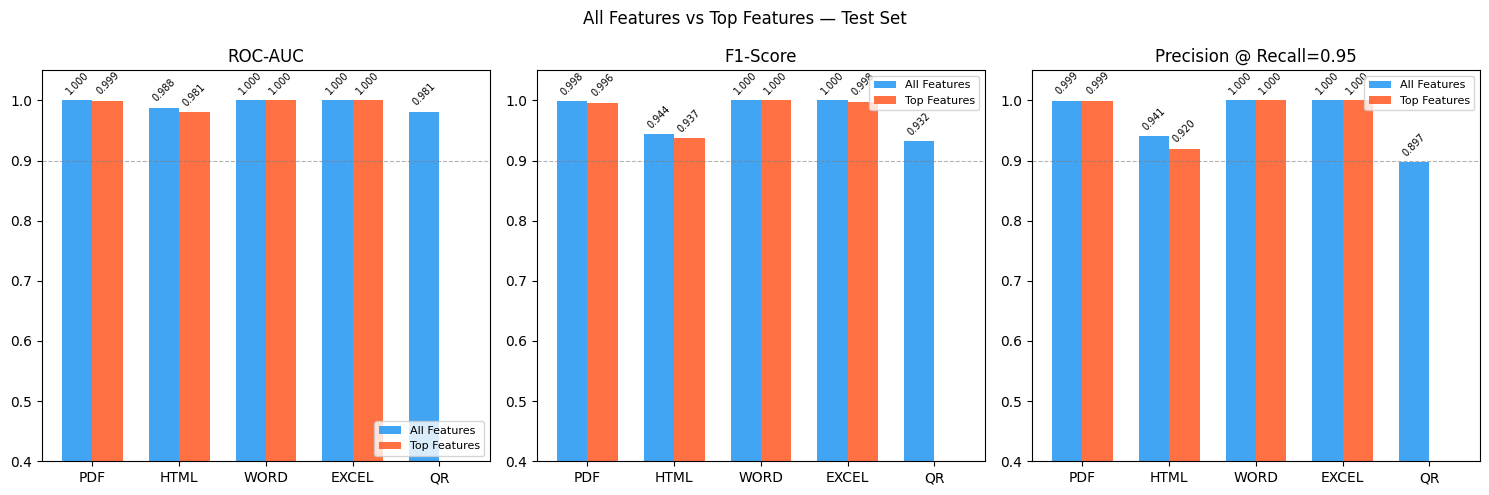

In [17]:
def full_evaluation(model, X_te, y_te, fmt: str, feat_names: list) -> dict:
    """Évaluation complète avec toutes les métriques pertinentes."""
    proba = model.predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int)
    
    auc  = roc_auc_score(y_te, proba)
    f1   = f1_score(y_te, preds)
    prec = precision_score(y_te, preds)
    rec  = recall_score(y_te, preds)
    
    # Precision @ Recall = 0.95
    prec_curve, rec_curve, thresholds = precision_recall_curve(y_te, proba)
    # Trouver le seuil qui donne recall ≥ 0.95
    mask = rec_curve >= 0.95
    p_at_r95 = prec_curve[mask].max() if mask.any() else 0.0
    
    return {
        'format': fmt, 'n_test': len(y_te),
        'auc': round(auc, 4), 'f1': round(f1, 4),
        'precision': round(prec, 4), 'recall': round(rec, 4),
        'p_at_r95': round(p_at_r95, 4),
    }


all_results = []

# Évaluation spécialisés ALL
for fmt in models_all:
    X_tr, y_tr, X_val, y_val, X_te, y_te, fn = splits[fmt]
    res = full_evaluation(models_all[fmt], X_te, y_te, f'ALL_{fmt}', fn)
    all_results.append(res)

# Évaluation spécialisés TOP
for fmt in models_top:
    X_tr, y_tr, X_val, y_val, X_te, y_te, fn = splits_top[fmt]
    res = full_evaluation(models_top[fmt], X_te, y_te, f'TOP_{fmt}', fn)
    all_results.append(res)

# Évaluation unifié
res_uni = full_evaluation(model_unified, X_te_u_s, y_te_u, 'UNIFIED', feat_u)
all_results.append(res_uni)

# QR CNN hybride
if qr_hybrid_model is not None:
    all_results.append({
        'format': 'QR_CNN_HYBRID', 'n_test': len(hybrid_partitions['test']['labels']),
        'auc': round(qr_test_auc, 4), 'f1': 0, 'precision': 0, 'recall': 0, 'p_at_r95': 0
    })

df_res = pd.DataFrame(all_results)
print("\n" + "═"*80)
print("RÉSULTATS FINAUX — TEST SET (une seule utilisation)")
print("═"*80)
print(df_res.to_string(index=False))

# ─── Plot comparatif ALL vs TOP ──────────────────────────────────
formats = [f for f in ['pdf','html','word','excel','qr'] if f in models_all]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, title in zip(axes,
    ['auc', 'f1', 'p_at_r95'],
    ['ROC-AUC', 'F1-Score', 'Precision @ Recall=0.95']):
    
    all_v = [df_res[df_res.format==f'ALL_{fmt}'][metric].values[0]
             if f'ALL_{fmt}' in df_res.format.values else 0 for fmt in formats]
    top_v = [df_res[df_res.format==f'TOP_{fmt}'][metric].values[0]
             if f'TOP_{fmt}' in df_res.format.values else 0 for fmt in formats]
    
    x = np.arange(len(formats)); w = 0.35
    ax.bar(x - w/2, all_v, w, label='All Features', color='#2196F3', alpha=0.85)
    ax.bar(x + w/2, top_v, w, label='Top Features', color='#FF5722', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels([f.upper() for f in formats])
    ax.set_ylim(0.4, 1.05); ax.set_title(title); ax.legend(fontsize=8)
    ax.axhline(0.9, color='gray', ls='--', lw=0.8, alpha=0.6)
    for i, (a, t) in enumerate(zip(all_v, top_v)):
        if a > 0: ax.text(i-w/2, a+0.01, f'{a:.3f}', ha='center', fontsize=7, rotation=45)
        if t > 0: ax.text(i+w/2, t+0.01, f'{t:.3f}', ha='center', fontsize=7, rotation=45)

plt.suptitle('All Features vs Top Features — Test Set', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 11 — Analyse des Erreurs & Diagnostic Surapprentissage

**Pourquoi analyser les erreurs ?**  
Un modèle parfait sur le test set peut quand même être fragile.  
L'analyse des faux positifs/négatifs révèle les cas difficiles et les limites réelles.


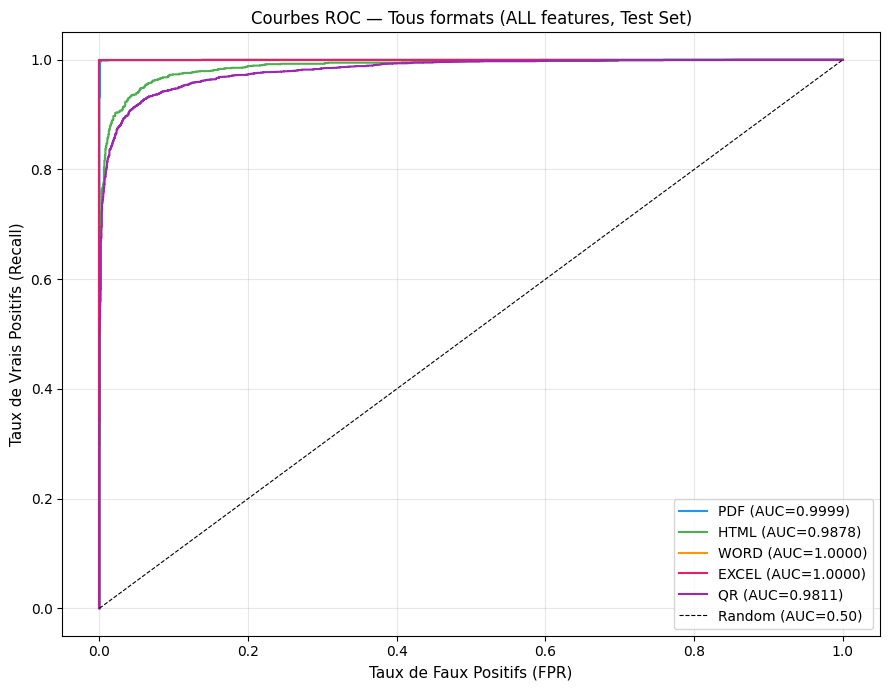


Format         AUC Train     AUC Val    AUC Test    Gap T-V  Verdict
───────────────────────────────────────────────────────────────────────────
ALL_pdf           1.0000      1.0000      0.9999     0.0000  ✅ Pas d'overfit
ALL_html          1.0000      0.9894      0.9878     0.0106  ✅ Pas d'overfit
ALL_word          1.0000      1.0000      1.0000     0.0000  ✅ Pas d'overfit  + ⚠️ AUC≈1 suspecte (confound dataset?)
ALL_excel         1.0000      1.0000      1.0000     0.0000  ✅ Pas d'overfit  + ⚠️ AUC≈1 suspecte (confound dataset?)
ALL_qr            0.9867      0.9830      0.9811     0.0037  ✅ Pas d'overfit

HTML — Analyse des erreurs (test set = 3,000 fichiers)
  Faux Positifs  :   76 (2.5%) — bénins mal classés
  Faux Négatifs  :   91 (3.0%) — malveillants manqués
  Vrais Positifs : 1409
  Vrais Négatifs : 1424


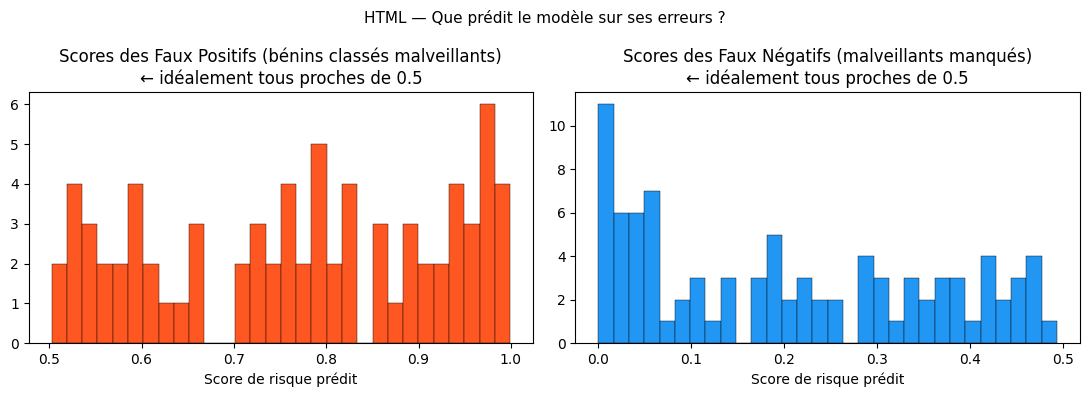

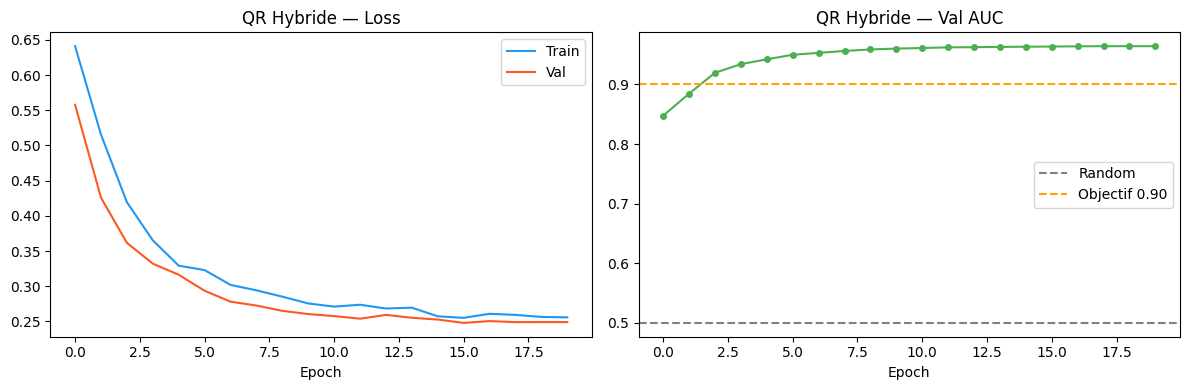

In [18]:
# ─── Courbes ROC superposées ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

for i, fmt in enumerate(models_all):
    X_tr, y_tr, X_val, y_val, X_te, y_te, fn = splits[fmt]
    proba = models_all[fmt].predict_proba(X_te)[:,1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    auc_score = roc_auc_score(y_te, proba)
    ax.plot(fpr, tpr, color=colors[i], lw=1.5,
            label=f'{fmt.upper()} (AUC={auc_score:.4f})')

ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random (AUC=0.50)')
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (Recall)', fontsize=11)
ax.set_title('Courbes ROC — Tous formats (ALL features, Test Set)', fontsize=12)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


# ─── Diagnostic surapprentissage ─────────────────────────────────
print(f"\n{'Format':<12} {'AUC Train':>11} {'AUC Val':>11} {'AUC Test':>11} {'Gap T-V':>10}  Verdict")
print("─"*75)

for fmt in models_all:
    X_tr, y_tr, X_val, y_val, X_te, y_te, fn = splits[fmt]
    m = models_all[fmt]
    auc_tr  = roc_auc_score(y_tr, m.predict_proba(X_tr)[:,1])
    auc_val = roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
    auc_te  = roc_auc_score(y_te, m.predict_proba(X_te)[:,1])
    gap = auc_tr - auc_val
    
    if gap < 0.02:    verdict = "✅ Pas d'overfit"
    elif gap < 0.05:  verdict = "⚠️  Overfit léger"
    else:             verdict = "🔴 Overfit significatif"
    
    if auc_te >= 0.9999:
        verdict += "  + ⚠️ AUC≈1 suspecte (confound dataset?)"
    
    print(f"ALL_{fmt:<8} {auc_tr:>11.4f} {auc_val:>11.4f} {auc_te:>11.4f} {gap:>10.4f}  {verdict}")


# ─── Analyse des faux positifs/négatifs ─────────────────────────
# Exemple sur HTML (le cas le plus réaliste)
if 'html' in models_all:
    X_tr, y_tr, X_val, y_val, X_te, y_te, fn = splits['html']
    m = models_all['html']
    proba = m.predict_proba(X_te)[:,1]
    preds = (proba >= 0.5).astype(int)
    
    fp_mask = (preds == 1) & (y_te.values == 0)  # Faux positifs (bénins classés malveillants)
    fn_mask = (preds == 0) & (y_te.values == 1)  # Faux négatifs (malveillants manqués)
    
    print(f"\nHTML — Analyse des erreurs (test set = {len(y_te):,} fichiers)")
    print(f"  Faux Positifs  : {fp_mask.sum():4d} ({fp_mask.mean()*100:.1f}%) — bénins mal classés")
    print(f"  Faux Négatifs  : {fn_mask.sum():4d} ({fn_mask.mean()*100:.1f}%) — malveillants manqués")
    print(f"  Vrais Positifs : {((preds==1)&(y_te.values==1)).sum():4d}")
    print(f"  Vrais Négatifs : {((preds==0)&(y_te.values==0)).sum():4d}")
    
    # Distribution des scores pour les erreurs
    if fp_mask.sum() > 0 and fn_mask.sum() > 0:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].hist(proba[fp_mask], bins=30, color='#FF5722', edgecolor='black', lw=0.3)
        axes[0].set_title('Scores des Faux Positifs (bénins classés malveillants)\n'
                          '← idéalement tous proches de 0.5')
        axes[0].set_xlabel('Score de risque prédit')
        
        axes[1].hist(proba[fn_mask], bins=30, color='#2196F3', edgecolor='black', lw=0.3)
        axes[1].set_title('Scores des Faux Négatifs (malveillants manqués)\n'
                          '← idéalement tous proches de 0.5')
        axes[1].set_xlabel('Score de risque prédit')
        
        plt.suptitle('HTML — Que prédit le modèle sur ses erreurs ?', fontsize=11)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'error_analysis_html.png', dpi=120, bbox_inches='tight')
        plt.show()

# ─── QR CNN history ──────────────────────────────────────────────
if qr_history and qr_history.get('val_auc'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(qr_history['train_loss'], label='Train', color='#2196F3')
    axes[0].plot(qr_history['val_loss'],   label='Val',   color='#FF5722')
    axes[0].set_title('QR Hybride — Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')
    
    axes[1].plot(qr_history['val_auc'], color='#4CAF50', marker='o', ms=4)
    axes[1].axhline(0.5, color='gray', ls='--', label='Random')
    axes[1].axhline(0.9, color='orange', ls='--', label='Objectif 0.90')
    axes[1].set_title('QR Hybride — Val AUC'); axes[1].legend(); axes[1].set_xlabel('Epoch')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'qr_hybrid_history.png', dpi=120, bbox_inches='tight')
    plt.show()


## Cellule 12 — SHAP : Comprendre ce que le modèle a appris

**Pourquoi SHAP plutôt que feature_importance ?**  
`feature_importance` de LightGBM mesure le nombre de fois qu'une feature est utilisée dans les arbres.  
SHAP mesure la **contribution directe de chaque feature à la prédiction** pour chaque sample.  
C'est la différence entre "cette feature est souvent utilisée" et "cette feature change vraiment la décision".


[PDF] Top 5 features :
  1. text_length                                         SHAP=4.3900  → bénin
  2. metadata_size                                       SHAP=0.7737  → bénin
  3. object_count                                        SHAP=0.7263  → malicious
  4. xfa_count                                           SHAP=0.5837  → bénin
  5. file_size                                           SHAP=0.3324  → malicious
[HTML] Top 5 features :
  1. url_punct_char_count                                SHAP=0.9684  → malicious
  2. keywords_to_words_ratio                             SHAP=0.7244  → malicious
  3. embedded_js_count                                   SHAP=0.6434  → bénin
  4. form_count                                          SHAP=0.6071  → malicious
  5. whitespace_ratio                                    SHAP=0.5564  → malicious
[WORD] Top 5 features :
  1. ole_object_count                                    SHAP=0.0999  → malicious
  2. struct_{http://schemas.openxmlformats.

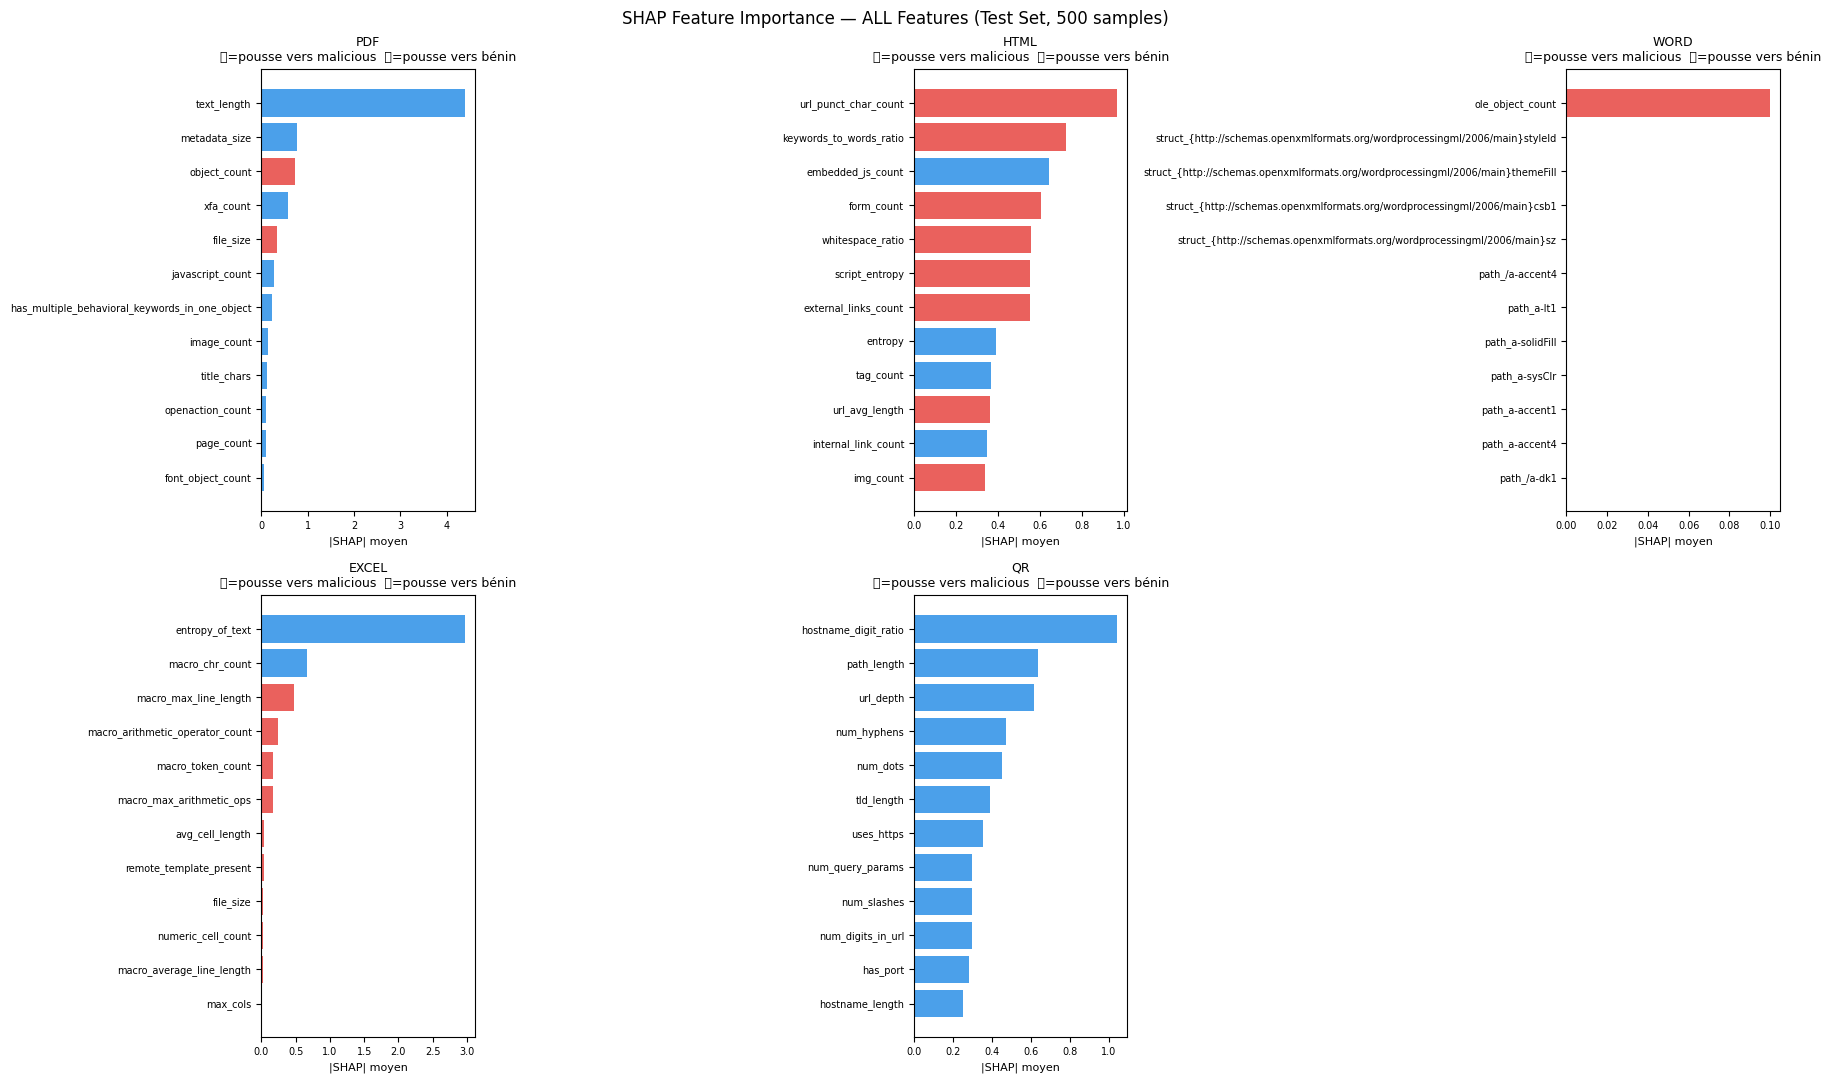

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, fmt in enumerate(models_all):
    X_tr, y_tr, X_val, y_val, X_te, y_te, feat_names = splits[fmt]
    model = models_all[fmt]
    
    n_exp = min(500, len(X_te))
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_te[:n_exp])
    
    mean_shap = np.abs(sv).mean(axis=0)
    top_idx = np.argsort(mean_shap)[::-1][:12]
    top_names = [feat_names[j] for j in reversed(top_idx)]
    top_vals  = [mean_shap[j] for j in reversed(top_idx)]
    
    # Couleur selon direction dominante (rouge = malicious, bleu = benign)
    direction_colors = []
    for j in reversed(top_idx):
        # Si SHAP moyen positif → feature pousse vers malicious
        mean_dir = sv[:, j].mean()
        direction_colors.append('#E53935' if mean_dir > 0 else '#1E88E5')
    
    axes[i].barh(top_names, top_vals, color=direction_colors, alpha=0.8)
    axes[i].set_title(f'{fmt.upper()}\n🔴=pousse vers malicious  🔵=pousse vers bénin', fontsize=9)
    axes[i].set_xlabel('|SHAP| moyen', fontsize=8)
    axes[i].tick_params(labelsize=7)
    
    print(f"[{fmt.upper()}] Top 5 features :")
    for rank, j in enumerate(top_idx[:5]):
        direction = "→ malicious" if sv[:,j].mean() > 0 else "→ bénin"
        print(f"  {rank+1}. {feat_names[j]:50s}  SHAP={mean_shap[j]:.4f}  {direction}")

for j in range(len(models_all), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('SHAP Feature Importance — ALL Features (Test Set, 500 samples)', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'shap_all_formats.png', dpi=150, bbox_inches='tight')
plt.show()


## Cellule 13 — Sauvegarde & Fonction d'Inférence Production

In [20]:
# ─── Sauvegarde ──────────────────────────────────────────────────
print("Sauvegarde des modèles...")
for fmt, m in models_all.items():
    joblib.dump(m, OUTPUT_DIR / f'lgbm_all_{fmt}.pkl')
    joblib.dump(scalers[fmt], OUTPUT_DIR / f'scaler_all_{fmt}.pkl')
    _, _, _, _, _, _, fn = splits[fmt]
    json.dump(fn, open(OUTPUT_DIR / f'features_all_{fmt}.json','w'))

for fmt, m in models_top.items():
    joblib.dump(m, OUTPUT_DIR / f'lgbm_top_{fmt}.pkl')
    joblib.dump(scalers_top[fmt], OUTPUT_DIR / f'scaler_top_{fmt}.pkl')
    _, _, _, _, _, _, fn = splits_top[fmt]
    json.dump(fn, open(OUTPUT_DIR / f'features_top_{fmt}.json','w'))

joblib.dump(model_unified, OUTPUT_DIR / 'lgbm_unified.pkl')
joblib.dump(sc_uni, OUTPUT_DIR / 'scaler_unified.pkl')
json.dump(feat_u, open(OUTPUT_DIR / 'features_unified.json','w'))

if qr_hybrid_model is not None:
    torch.save({'model': qr_hybrid_model.state_dict(),
                'url_scaler': qr_url_scaler,
                'url_feat_names': URL_FEAT_NAMES},
               OUTPUT_DIR / 'qr_hybrid_final.pt')

json.dump(all_results, open(OUTPUT_DIR / 'results_v3.json', 'w'), indent=2)
print(f"✅ {len(list(OUTPUT_DIR.iterdir()))} fichiers dans {OUTPUT_DIR.resolve()}")


# ─── Fonction d'inférence ─────────────────────────────────────────
def predict(file_features: dict, fmt: str, model_set: str = 'all') -> dict:
    """
    Fonction d'inférence production.
    
    Paramètres
    ----------
    file_features : dict des features extraites du fichier (depuis vos extracteurs)
    fmt           : 'pdf' | 'html' | 'word' | 'excel' | 'qr'
    model_set     : 'all' (toutes features) ou 'top' (features sélectionnées)
    
    Retourne
    --------
    dict avec risk_score, label, action recommandée, top features SHAP
    """
    if model_set == 'all':
        model = models_all.get(fmt)
        scaler = scalers.get(fmt)
        _, _, _, _, _, _, feat_names = splits.get(fmt, (None,)*7)
    else:
        model = models_top.get(fmt)
        scaler = scalers_top.get(fmt)
        _, _, _, _, _, _, feat_names = splits_top.get(fmt, (None,)*7)
    
    if model is None or feat_names is None:
        return {'error': f"Format '{fmt}' non disponible avec model_set='{model_set}'"}
    
    X = np.array([[file_features.get(f, 0) for f in feat_names]], dtype=float)
    X_s = scaler.transform(X)
    
    risk_score = float(model.predict_proba(X_s)[0, 1])
    label = 'malicious' if risk_score >= 0.5 else 'benign'
    
    # SHAP pour cette instance
    exp = shap.TreeExplainer(model)
    sv = exp.shap_values(X_s)[0]
    top5_idx = np.argsort(np.abs(sv))[::-1][:5]
    
    return {
        'format':     fmt,
        'label':      label,
        'risk_score': round(risk_score, 4),
        'confidence': round(abs(risk_score - 0.5) * 2, 4),  # 0=incertain, 1=très confiant
        'action':     'BLOCK'  if risk_score > 0.80 else
                      'REVIEW' if risk_score > 0.50 else 'ALLOW',
        'top_features': [
            {'name': feat_names[i], 'shap': round(float(sv[i]), 4),
             'direction': '→ malicious' if sv[i] > 0 else '→ benign'}
            for i in top5_idx
        ],
    }


# ─── Démo ─────────────────────────────────────────────────────────
print("\n=== DÉMO — Prédictions exemples ===\n")

# HTML : page de phishing évidente
demo_html = {
    'form_count': 3, 'embedded_js_count': 8, 'iframe_count': 2,
    'keywords_to_words_ratio': 0.15, 'redirect_mechanism_count': 4,
    'url_punct_char_count': 45, 'script_entropy': 6.8,
    'whitespace_ratio': 0.02, 'url_digit_count': 12,
}
res = predict(demo_html, 'html')
print(f"HTML phishing évident → {res['label']} ({res['risk_score']:.3f}) [{res['action']}]")
for f in res['top_features'][:3]:
    print(f"  {f['name']:40s} SHAP={f['shap']:+.4f}  {f['direction']}")

print()
# HTML : page normale
demo_html_ok = {
    'form_count': 0, 'embedded_js_count': 1, 'iframe_count': 0,
    'keywords_to_words_ratio': 0.0, 'redirect_mechanism_count': 0,
    'url_punct_char_count': 5, 'script_entropy': 3.2,
}
res2 = predict(demo_html_ok, 'html')
print(f"HTML bénin            → {res2['label']} ({res2['risk_score']:.3f}) [{res2['action']}]")


Sauvegarde des modèles...
✅ 42 fichiers dans C:\Users\karim\Documents\CIC\models_v3

=== DÉMO — Prédictions exemples ===

HTML phishing évident → malicious (0.997) [BLOCK]
  whitespace_ratio                         SHAP=+1.8844  → malicious
  html_whitespace_ratio                    SHAP=+1.8296  → malicious
  line_count                               SHAP=+1.5324  → malicious

HTML bénin            → malicious (0.997) [BLOCK]
